# Crowd Density Classification Framework
### Multi-Dataset CNN + Two Transfer Learning Models
**Datasets:** ShanghaiTech · JHU-CROWD++ · Abnormal High-Density Crowds (balanced via data-driven thresholds)  
**Classes:** Low | Medium | High | Very High  
**Models:** Custom CNN | ResNet50 (Transfer Learning) | EfficientNetB0 (Transfer Learning)  
**Goal:** Classify crowd images into 4 density levels to support early detection of dangerous overcrowding (stampede/crowd-crush risk).

## 1. Import Libraries & Multi-GPU Setup

In [1]:
import os, glob, random, time
from collections import Counter
import numpy as np
import pandas as pd
import scipy.io
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2, EfficientNetB0
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_curve, auc,
    precision_score, recall_score, f1_score
)
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight

print('TensorFlow version:', tf.__version__)
print('GPU available:', tf.config.list_physical_devices('GPU'))

# ── Clear any existing TF session first ──────────────────────────────────────
tf.keras.backend.clear_session()

# ── Multi-GPU Strategy ────────────────────────────────────────────────────────
try:
    strategy = tf.distribute.MirroredStrategy()
    print('Number of GPUs in use:', strategy.num_replicas_in_sync)
except:
    strategy = tf.distribute.get_default_strategy()
    print('Using default strategy (single GPU)')

2026-06-22 17:07:40.815243: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782148061.224926      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782148061.345262      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782148062.372915      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782148062.372960      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782148062.372963      58 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')
Number of GPUs in use: 2


I0000 00:00:1782148082.141938      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1782148082.148235      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [24]:
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

## 2. Configuration & Balanced Multi-Dataset Loading

Instead of fixed thresholds, this version computes **data-driven density thresholds** using the 25th/50th/75th percentiles of head counts from ShanghaiTech + JHU-CROWD++. This naturally produces ~25% of images per class for those two datasets.

The Abnormal High-Density dataset (all "Very High") is then used only to **top up** the Very High class up to `VERYHIGH_RATIO_CAP × average(Low, Medium, High)` — preventing it from dominating the dataset like before.

In [2]:
# ── CONFIG ──────────────────────────────────────────────────────────────────
IMG_SIZE        = (128, 128)   # CNN uses 128x128
IMG_SIZE_TL     = (224, 224)   # Transfer learning uses 224x224
BATCH_SIZE      = 32
EPOCHS_CNN      = 60
SEED            = 42
CLASS_NAMES     = ['Low', 'Medium', 'High', 'Very High']
colors          = ['#4CAF50', '#2196F3', '#FF9800', '#F44336']
ABNORMAL_TARGET = 2000

tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

# ── DATASET ROOTS ─────────────────────────────────────────────────────────────
ROOT_SHANGHAI = '/kaggle/input/datasets/tthien/shanghaitech/ShanghaiTech'
ROOT_JHU      = '/kaggle/input/datasets/hoangxuanviet/jhu-crowd'
ROOT_ABNORMAL = '/kaggle/input/datasets/angelchi56/abnormal-highdensity-crowds/Abnormal High-density Crowds'

# ── PASS 1: collect paths + counts (NO image decoding) ────────────────────────
def collect_counts():
    items = []
    subsets = [('part_A','train_data'), ('part_A','test_data'),
               ('part_B','train_data'), ('part_B','test_data')]
    for part, split in subsets:
        gt_dir  = os.path.join(ROOT_SHANGHAI, part, split, 'ground-truth')
        img_dir = os.path.join(ROOT_SHANGHAI, part, split, 'images')
        if not os.path.isdir(gt_dir): continue
        for mat_file in os.listdir(gt_dir):
            if not mat_file.endswith('.mat'): continue
            img_name = mat_file.replace('GT_','').replace('.mat','.jpg')
            img_path = os.path.join(img_dir, img_name)
            if not os.path.exists(img_path): continue
            mat   = scipy.io.loadmat(os.path.join(gt_dir, mat_file))
            count = len(mat['image_info'][0][0][0][0][0])
            items.append((img_path, count))
    n_shanghai = len(items)
    print(f'  ShanghaiTech candidates : {n_shanghai}')
    for split in ['train', 'test', 'valid']:
        img_dir = os.path.join(ROOT_JHU, split, 'images')
        lbl_dir = os.path.join(ROOT_JHU, split, 'labels')
        if not os.path.isdir(img_dir): continue
        for fname in os.listdir(img_dir):
            if not fname.lower().endswith(('.jpg','.jpeg','.png')): continue
            base     = os.path.splitext(fname)[0]
            lbl_path = os.path.join(lbl_dir, base + '.txt')
            if not os.path.exists(lbl_path): continue
            with open(lbl_path) as f:
                count = sum(1 for line in f if line.strip())
            items.append((os.path.join(img_dir, fname), count))
    print(f'  JHU-CROWD++ candidates  : {len(items) - n_shanghai}')
    return items

print('Pass 1/3 — scanning annotations...')
items      = collect_counts()
counts_arr = np.array([c for _, c in items])

# ── Tercile thresholds (3-way split for Low/Medium/High) ──────────────────────
T1, T2 = np.percentile(counts_arr, [33.33, 66.67])
print(f'\nThresholds: Low≤{T1:.0f} | Medium {T1:.0f}-{T2:.0f} | High>{T2:.0f}')
print(f'Very High : from Abnormal High-Density dataset only')

def assign_label(count):
    if   count <= T1: return 0
    elif count <= T2: return 1
    else:             return 2

# ── PASS 2: collect paths + labels only (NO image decoding) ───────────────────
print('\nPass 2/3 — collecting paths + labels...')
all_paths, all_labels = [], []
for path, count in items:
    if os.path.exists(path):
        all_paths.append(path)
        all_labels.append(assign_label(count))

# ── PASS 3: add Abnormal paths as Very High ────────────────────────────────────
print(f'\nPass 3/3 — adding {ABNORMAL_TARGET} Abnormal images as Very High...')
added = 0
for scene in os.listdir(ROOT_ABNORMAL):
    if added >= ABNORMAL_TARGET: break
    scene_path = os.path.join(ROOT_ABNORMAL, scene)
    if not os.path.isdir(scene_path): continue
    for sub in os.listdir(scene_path):
        if added >= ABNORMAL_TARGET: break
        sub_path = os.path.join(scene_path, sub)
        if not os.path.isdir(sub_path): continue
        for fname in os.listdir(sub_path):
            if added >= ABNORMAL_TARGET: break
            if not fname.lower().endswith(('.jpg','.jpeg','.png')): continue
            full_path = os.path.join(sub_path, fname)
            if os.path.exists(full_path):
                all_paths.append(full_path)
                all_labels.append(3)
                added += 1
print(f'  Abnormal added: {added} images')

all_paths  = np.array(all_paths)
all_labels = np.array(all_labels, dtype=np.int32)
print(f'\n✅ Total paths: {len(all_paths)}')
print(f'   Class distribution: {dict(zip(CLASS_NAMES, [np.sum(all_labels==i) for i in range(4)]))}')

# ── SPLIT paths (not images) ──────────────────────────────────────────────────
paths_tv, paths_test, labels_tv, labels_test = train_test_split(
    all_paths, all_labels, test_size=0.20, stratify=all_labels, random_state=SEED)
paths_train, paths_val, labels_train, labels_val = train_test_split(
    paths_tv, labels_tv, test_size=0.25, stratify=labels_tv, random_state=SEED)
print(f'Train: {len(paths_train)} | Val: {len(paths_val)} | Test: {len(paths_test)}')

# ── CLASS WEIGHTS ──────────────────────────────────────────────────────────────
class_weights = compute_class_weight('balanced',
                                     classes=np.unique(labels_train),
                                     y=labels_train)
class_weight_dict = dict(enumerate(class_weights))
print('Class weights:', {CLASS_NAMES[k]: round(v,3) for k,v in class_weight_dict.items()})

# ── tf.data PIPELINE — CNN (128x128) ──────────────────────────────────────────
def load_and_augment_cnn(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_brightness(img, max_delta=0.2)
    img = tf.image.random_contrast(img, lower=0.8, upper=1.2)
    img = tf.image.random_saturation(img, lower=0.8, upper=1.2)
    img = tf.clip_by_value(img, 0.0, 1.0)
    return img, tf.one_hot(label, depth=4)

def load_only_cnn(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    return img, tf.one_hot(label, depth=4)

# ── tf.data PIPELINE — Transfer Learning (224x224) ────────────────────────────
def load_and_augment_tl(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE_TL)
    img = tf.cast(img, tf.float32) / 255.0
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_brightness(img, max_delta=0.2)
    img = tf.image.random_contrast(img, lower=0.8, upper=1.2)
    img = tf.clip_by_value(img, 0.0, 1.0)
    return img, tf.one_hot(label, depth=4)

def load_only_tl(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE_TL)
    img = tf.cast(img, tf.float32) / 255.0
    return img, tf.one_hot(label, depth=4)

# CNN datasets
train_ds_cnn = (tf.data.Dataset.from_tensor_slices((paths_train, labels_train))
                .shuffle(2000, seed=SEED)
                .map(load_and_augment_cnn, num_parallel_calls=tf.data.AUTOTUNE)
                .batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE))

val_ds_cnn   = (tf.data.Dataset.from_tensor_slices((paths_val, labels_val))
                .map(load_only_cnn, num_parallel_calls=tf.data.AUTOTUNE)
                .batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE))

test_ds_cnn  = (tf.data.Dataset.from_tensor_slices((paths_test, labels_test))
                .map(load_only_cnn, num_parallel_calls=tf.data.AUTOTUNE)
                .batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE))

# TL datasets
train_ds_tl  = (tf.data.Dataset.from_tensor_slices((paths_train, labels_train))
                .shuffle(2000, seed=SEED)
                .map(load_and_augment_tl, num_parallel_calls=tf.data.AUTOTUNE)
                .batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE))

val_ds_tl    = (tf.data.Dataset.from_tensor_slices((paths_val, labels_val))
                .map(load_only_tl, num_parallel_calls=tf.data.AUTOTUNE)
                .batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE))

test_ds_tl   = (tf.data.Dataset.from_tensor_slices((paths_test, labels_test))
                .map(load_only_tl, num_parallel_calls=tf.data.AUTOTUNE)
                .batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE))

# ── Small numpy sample for Grad-CAM ───────────────────────────────────────────
print('\nPreparing Grad-CAM numpy sample...')
gradcam_images, gradcam_labels = [], []
for path, label in zip(paths_test[:200], labels_test[:200]):
    img = cv2.imread(path)
    if img is None: continue
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, IMG_SIZE)
    gradcam_images.append(img.astype(np.float32) / 255.0)
    gradcam_labels.append(label)
X_gradcam = np.array(gradcam_images)
y_gradcam = np.array(gradcam_labels)
print(f'Grad-CAM sample ready: {X_gradcam.shape}')
print('\n All pipelines ready! ')

Pass 1/3 — scanning annotations...
  ShanghaiTech candidates : 1198
  JHU-CROWD++ candidates  : 4360

Thresholds: Low≤66 | Medium 66-208 | High>208
Very High : from Abnormal High-Density dataset only

Pass 2/3 — collecting paths + labels...

Pass 3/3 — adding 2000 Abnormal images as Very High...
  Abnormal added: 2000 images

✅ Total paths: 7558
   Class distribution: {'Low': np.int64(1869), 'Medium': np.int64(1842), 'High': np.int64(1847), 'Very High': np.int64(2000)}
Train: 4534 | Val: 1512 | Test: 1512
Class weights: {'Low': np.float64(1.011), 'Medium': np.float64(1.026), 'High': np.float64(1.023), 'Very High': np.float64(0.945)}

Preparing Grad-CAM numpy sample...
Grad-CAM sample ready: (200, 128, 128, 3)

 All pipelines ready! 


## 3. Class Distribution

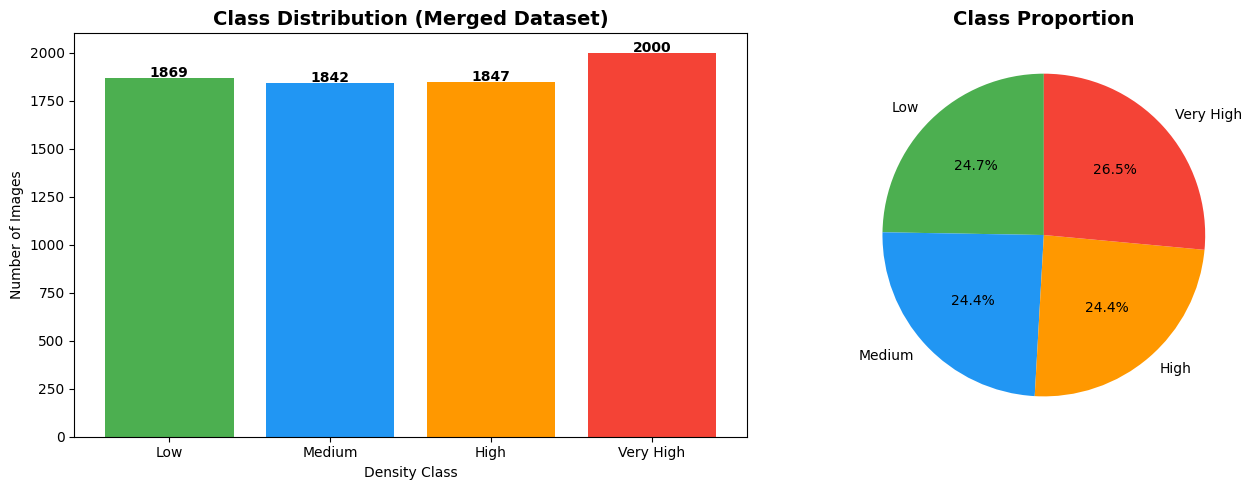

Class counts: {'Low': np.int64(1869), 'Medium': np.int64(1842), 'High': np.int64(1847), 'Very High': np.int64(2000)}


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
class_counts_arr = np.array([np.sum(all_labels==i) for i in range(4)])
axes[0].bar(CLASS_NAMES, class_counts_arr, color=colors)
axes[0].set_title('Class Distribution (Merged Dataset)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Density Class')
axes[0].set_ylabel('Number of Images')
for i, v in enumerate(class_counts_arr):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')
axes[1].pie(class_counts_arr,
            labels=CLASS_NAMES,
            autopct='%1.1f%%', colors=colors, startangle=90)
axes[1].set_title('Class Proportion', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Class counts:', dict(zip(CLASS_NAMES, class_counts_arr)))

## 4. Sample Images per Class

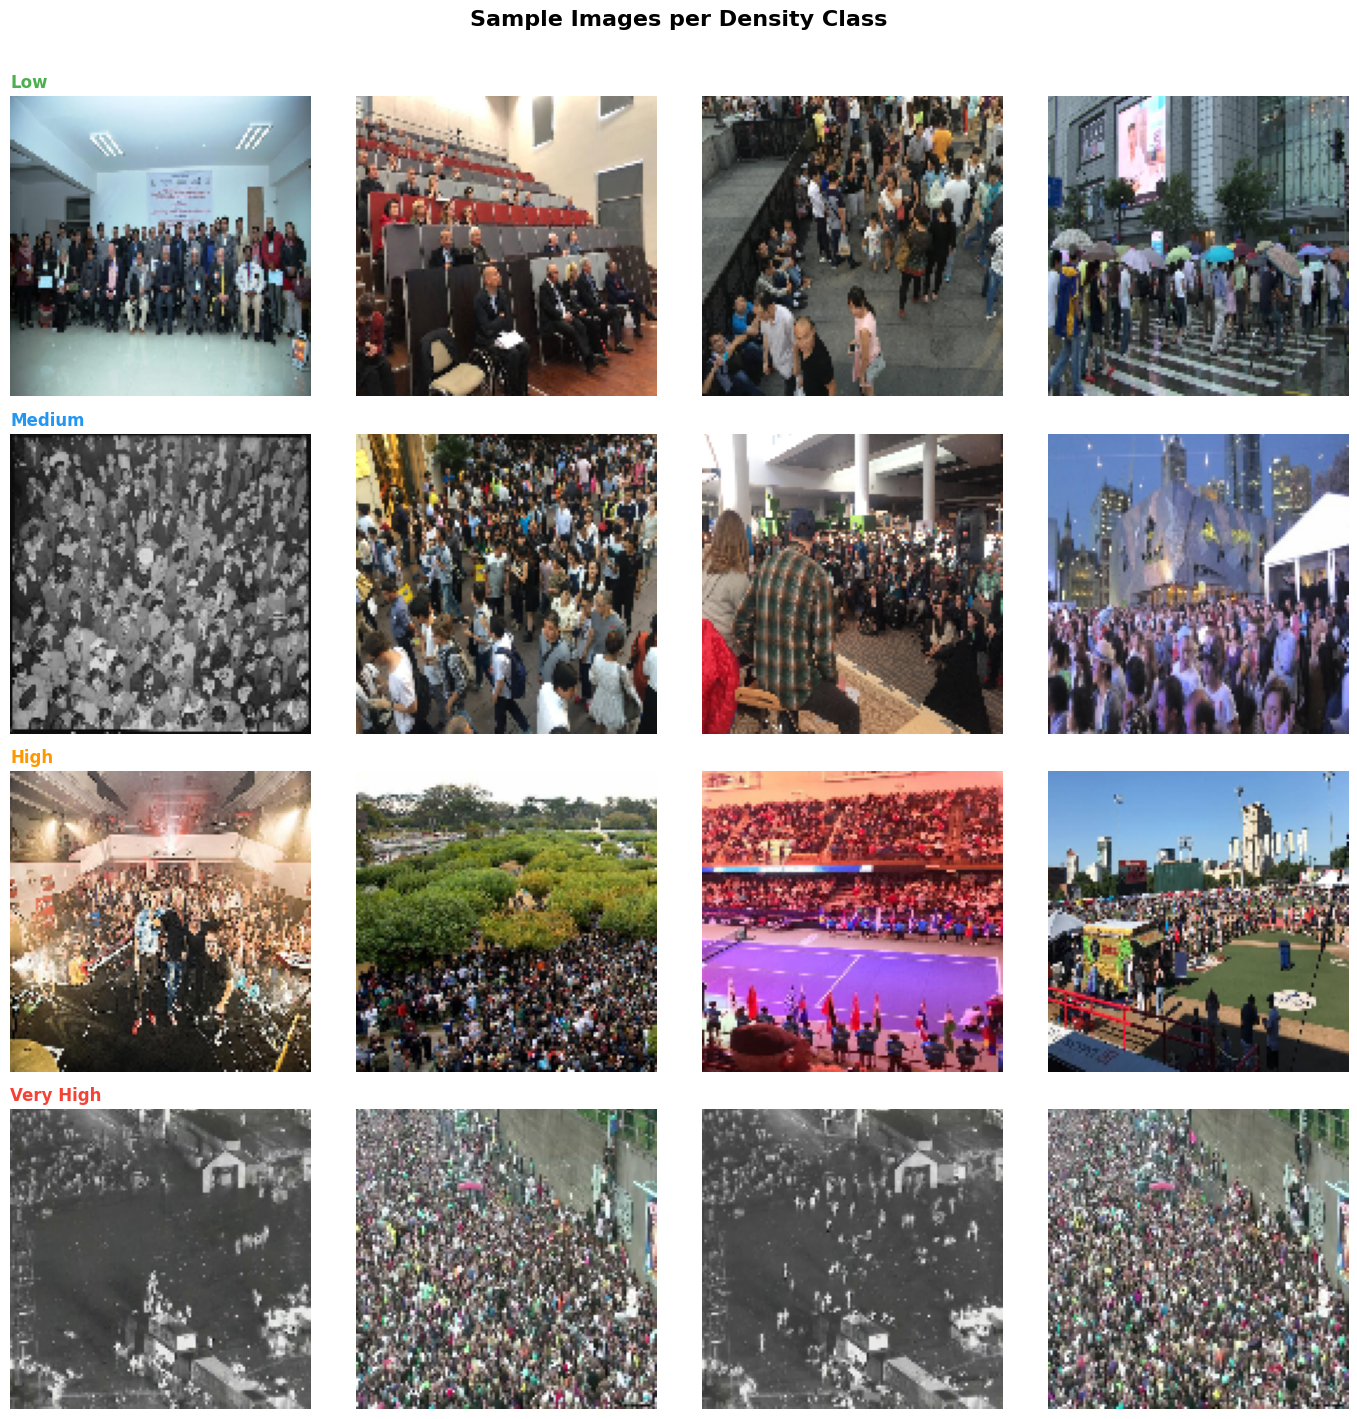

In [4]:
fig, axes = plt.subplots(4, 4, figsize=(14, 14))
for cls_idx, cls_name in enumerate(CLASS_NAMES):
    cls_paths = paths_train[labels_train == cls_idx]
    sample_paths = np.random.choice(cls_paths, size=min(4, len(cls_paths)), replace=False)
    for col, path in enumerate(sample_paths):
        img = cv2.imread(path)
        if img is None: continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, IMG_SIZE)
        ax = axes[cls_idx][col]
        ax.imshow(img)
        ax.axis('off')
        if col == 0:
            ax.set_title(f'{cls_name}', fontsize=12,
                        fontweight='bold', color=colors[cls_idx], loc='left')
plt.suptitle('Sample Images per Density Class', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Train / Validation / Test Split

In [5]:
# Split already done in Cell 2 using paths
# This cell confirms everything and sets up y_true for evaluation

print(f'Train      : {len(paths_train)} images')
print(f'Validation : {len(paths_val)} images')
print(f'Test       : {len(paths_test)} images')
print(f'Total      : {len(all_paths)} images')

# y_true for evaluation (test set labels)
y_true = labels_test.copy()

# Confirm class distribution in each split
print(f'\nTrain class distribution:')
for i, name in enumerate(CLASS_NAMES):
    print(f'  {name}: {np.sum(labels_train==i)}')

print(f'\nTest class distribution:')
for i, name in enumerate(CLASS_NAMES):
    print(f'  {name}: {np.sum(labels_test==i)}')

print(f'\nClass weights: {dict(zip(CLASS_NAMES, [round(class_weight_dict[i],3) for i in range(4)]))}')
print('\n Ready for training!')

Train      : 4534 images
Validation : 1512 images
Test       : 1512 images
Total      : 7558 images

Train class distribution:
  Low: 1121
  Medium: 1105
  High: 1108
  Very High: 1200

Test class distribution:
  Low: 374
  Medium: 368
  High: 370
  Very High: 400

Class weights: {'Low': np.float64(1.011), 'Medium': np.float64(1.026), 'High': np.float64(1.023), 'Very High': np.float64(0.945)}

 Ready for training!


## 6. Data Augmentation

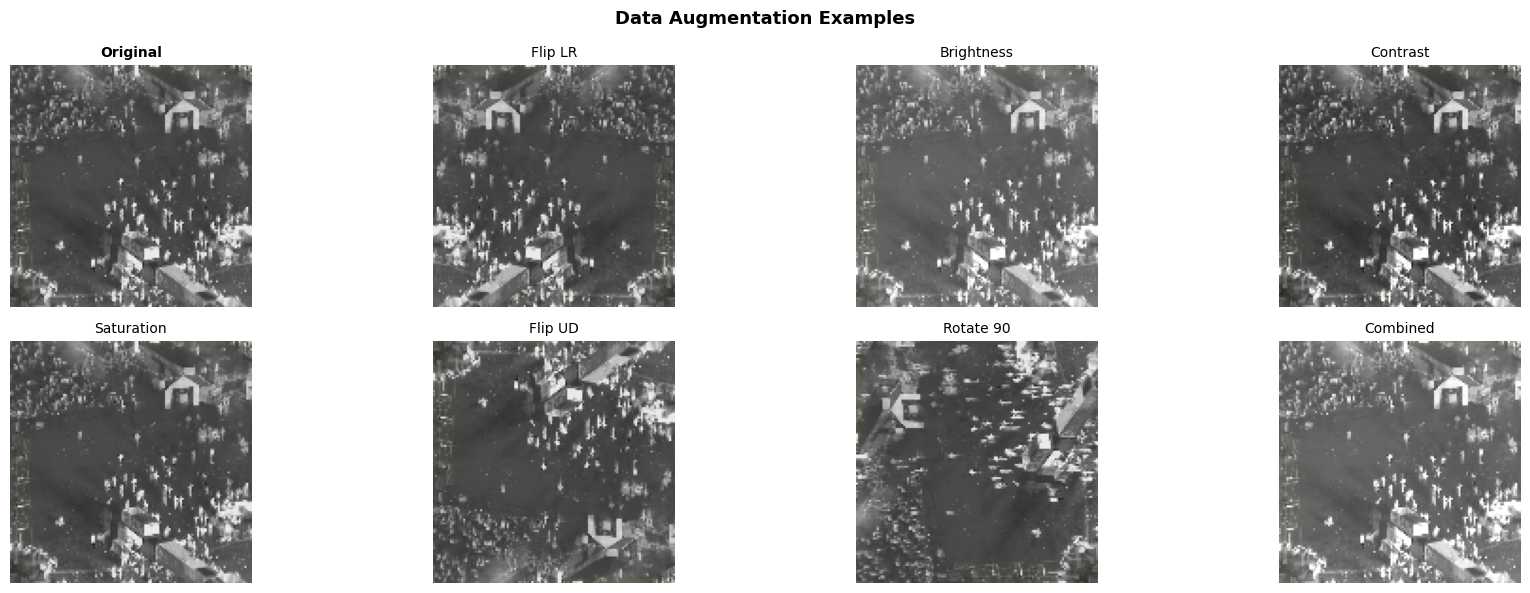

 Augmentation examples saved!


In [6]:
# Augmentation is now handled inside the tf.data pipeline (Cell 2)
# This cell just shows augmentation examples visually

import matplotlib.gridspec as gridspec

# Show augmentation examples using one sample image
sample_path = paths_train[0]
img = cv2.imread(sample_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img, IMG_SIZE)
img = img.astype(np.float32) / 255.0

fig, axes = plt.subplots(2, 4, figsize=(18, 6))
axes = axes.flatten()

# Original
axes[0].imshow(img)
axes[0].set_title('Original', fontsize=10, fontweight='bold')
axes[0].axis('off')

# 7 augmented versions
aug_fns = [
    lambda x: tf.image.flip_left_right(x).numpy(),
    lambda x: tf.image.random_brightness(x, 0.3).numpy(),
    lambda x: tf.image.random_contrast(x, 0.6, 1.4).numpy(),
    lambda x: tf.image.random_saturation(x, 0.6, 1.4).numpy(),
    lambda x: tf.image.flip_up_down(x).numpy(),
    lambda x: tf.image.rot90(x).numpy(),
    lambda x: tf.clip_by_value(
        tf.image.random_brightness(
        tf.image.random_contrast(x, 0.7, 1.3), 0.2), 0, 1).numpy(),
]
aug_names = ['Flip LR', 'Brightness', 'Contrast',
             'Saturation', 'Flip UD', 'Rotate 90', 'Combined']

for i, (fn, name) in enumerate(zip(aug_fns, aug_names)):
    try:
        aug_img = np.clip(fn(img), 0, 1)
        axes[i+1].imshow(aug_img)
        axes[i+1].set_title(name, fontsize=10)
        axes[i+1].axis('off')
    except:
        axes[i+1].axis('off')

plt.suptitle('Data Augmentation Examples', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('augmentation_examples.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Augmentation examples saved!')

## 7. Custom CNN Architecture (Baseline)

In [15]:
def build_custom_cnn(input_shape=(128, 128, 3), num_classes=4):
    inputs = keras.Input(shape=input_shape)

    # Block 1
    x = layers.Conv2D(32, (3,3), padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(32, (3,3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Dropout(0.2)(x)

    # Block 2
    x = layers.Conv2D(64, (3,3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(64, (3,3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Dropout(0.2)(x)

    # Block 3
    x = layers.Conv2D(128, (3,3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(128, (3,3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Dropout(0.3)(x)

    # Block 4 — SeparableConv
    x = layers.SeparableConv2D(256, (3,3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.SeparableConv2D(256, (3,3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Dropout(0.3)(x)

    # Block 5 — SeparableConv
    x = layers.SeparableConv2D(512, (3,3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Dropout(0.4)(x)

    # Dual pooling
    gap = layers.GlobalAveragePooling2D()(x)
    gmp = layers.GlobalMaxPooling2D()(x)
    x = layers.Concatenate()([gap, gmp])

    # Classifier head
    x = layers.Dense(512, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.35)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = keras.Model(inputs, outputs, name='Custom_CNN')
    return model

with strategy.scope():
    cnn_model = build_custom_cnn()
cnn_model.summary()

Model: "Custom_CNN"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_12 (Conv2D)  │ (None, 128, 128,  │        896 │ input_layer_6[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        128 │ conv2d_12[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_18       │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_13 (Conv2D)  │ (None, 128, 128,  │      9,248 │ activation_18[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        128 │ conv2d_13[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_19       │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_10    │ (None, 64, 64,    │          0 │ activation_19[0]… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_18          │ (None, 64, 64,    │          0 │ max_pooling2d_10… │
│ (Dropout)           │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_14 (Conv2D)  │ (None, 64, 64,    │     18,496 │ dropout_18[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_14[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_20       │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_15 (Conv2D)  │ (None, 64, 64,    │     36,928 │ activation_20[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_15[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_21       │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_11    │ (None, 32, 32,    │          0 │ activation_21[0]… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_19          │ (None, 32, 32,    │          0 │ max_pooling2d_11

 Total params: 1,189,284 (4.54 MB)

 Trainable params: 1,184,804 (4.52 MB)

 Non-trainable params: 4,480 (17.50 KB)

In [12]:
# Check how many validation paths come from Abnormal dataset
abnormal_in_val = sum(1 for p in paths_val if 'abnormal' in p.lower() or 'angelchi' in p.lower())
print(f'Abnormal images in validation: {abnormal_in_val}/{len(paths_val)}')

# Check for any non-image files in paths
extensions = {}
for p in paths_val:
    ext = p.split('.')[-1].lower()
    extensions[ext] = extensions.get(ext, 0) + 1
print(f'File extensions in val set: {extensions}')

# Try loading first 5 val images and check
print('\nTesting first 5 val images:')
for i, (p, l) in enumerate(zip(paths_val[:5], labels_val[:5])):
    img = cv2.imread(p)
    status = 'OK' if img is not None else 'FAILED'
    print(f'  {status} | label={CLASS_NAMES[l]} | {p[-60:]}')

Abnormal images in validation: 400/1512
File extensions in val set: {'jpg': 1112, 'png': 400}

Testing first 5 val images:
  OK | label=High | shanghaitech/ShanghaiTech/part_B/test_data/images/IMG_96.jpg
  OK | label=Low | test/images/1870_jpg.rf.e2033992e57c8a3aa3442d6cac5b7952.jpg
  OK | label=Low | anghaitech/ShanghaiTech/part_B/train_data/images/IMG_128.jpg
  OK | label=Low | rain/images/1664_jpg.rf.345b7a5d9b6a95fc99a44b5b52d0846b.jpg
  OK | label=High | rain/images/0864_jpg.rf.0d851b5b4e7ad824ffbbc3fd6b148e60.jpg


## 8. Train Custom CNN

In [16]:
import cv2

# Load val and test into numpy directly — small enough, fixes the GPU distribution bug
print('Loading val set into numpy...')
X_val_np, y_val_np = [], []
for path, label in zip(paths_val, labels_val):
    img = cv2.imread(path)
    if img is None: continue
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, IMG_SIZE)
    X_val_np.append(img.astype(np.float32) / 255.0)
    y_val_np.append(label)
X_val_np = np.array(X_val_np)
y_val_cat = to_categorical(np.array(y_val_np), num_classes=4)
print(f'Val set loaded: {X_val_np.shape}')

print('Loading test set into numpy...')
X_test_np, y_test_np = [], []
for path, label in zip(paths_test, labels_test):
    img = cv2.imread(path)
    if img is None: continue
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, IMG_SIZE)
    X_test_np.append(img.astype(np.float32) / 255.0)
    y_test_np.append(label)
X_test_np = np.array(X_test_np)
y_test_cat = to_categorical(np.array(y_test_np), num_classes=4)
y_true = np.array(y_test_np)
print(f'Test set loaded: {X_test_np.shape}')

# Rebuild model fresh
with strategy.scope():
    cnn_model = build_custom_cnn()
    cnn_model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

callbacks_cnn = [
    EarlyStopping(monitor='val_loss', patience=15,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=5, min_lr=1e-7, verbose=1),
    ModelCheckpoint('best_cnn_model.keras', monitor='val_accuracy',
                    save_best_only=True, verbose=1),
]

cnn_history = cnn_model.fit(
    train_ds_cnn,
    validation_data=(X_val_np, y_val_cat),
    epochs=EPOCHS_CNN,
    callbacks=callbacks_cnn,
    class_weight=class_weight_dict,
    verbose=1
)
print('\n Custom CNN training complete!')

Loading val set into numpy...
Val set loaded: (1512, 128, 128, 3)
Loading test set into numpy...
Test set loaded: (1512, 128, 128, 3)
Epoch 1/60
INFO:tensorflow:Collective all_reduce tensors: 49 all_reduces, num_devices = 2, group_size = 2, implementation = CommunicationImplementation.NCCL, num_packs = 1


E0000 00:00:1782150207.855674      58 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/Custom_CNN_1/dropout_25_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step - accuracy: 0.4080 - loss: 1.5617
Epoch 1: val_accuracy improved from None to 0.26455, saving model to best_cnn_model.keras

Epoch 1: finished saving model to best_cnn_model.keras
142/142 ━━━━━━━━━━━━━━━━━━━━ 39s 208ms/step - accuracy: 0.4715 - loss: 1.3300 - val_accuracy: 0.2646 - val_loss: 7.3560 - learning_rate: 0.0010
Epoch 2/60
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step - accuracy: 0.5731 - loss: 0.9891
Epoch 2: val_accuracy did not improve from 0.26455
142/142 ━━━━━━━━━━━━━━━━━━━━ 26s 184ms/step - accuracy: 0.5924 - loss: 0.9589 - val_accuracy: 0.2646 - val_loss: 10.4440 - learning_rate: 0.0010
Epoch 3/60
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step - accuracy: 0.6321 - loss: 0.8487
Epoch 3: val_accuracy did not improve from 0.26455
142/142 ━━━━━━━━━━━━━━━━━━━━ 26s 185ms/step - accuracy: 0.6348 - loss: 0.8495 - val_accuracy: 0.2646 - val_loss: 10.0128 - learning_rate: 0.0010
Epoch 4/60
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step - accuracy:

## 9. CNN Training Curves

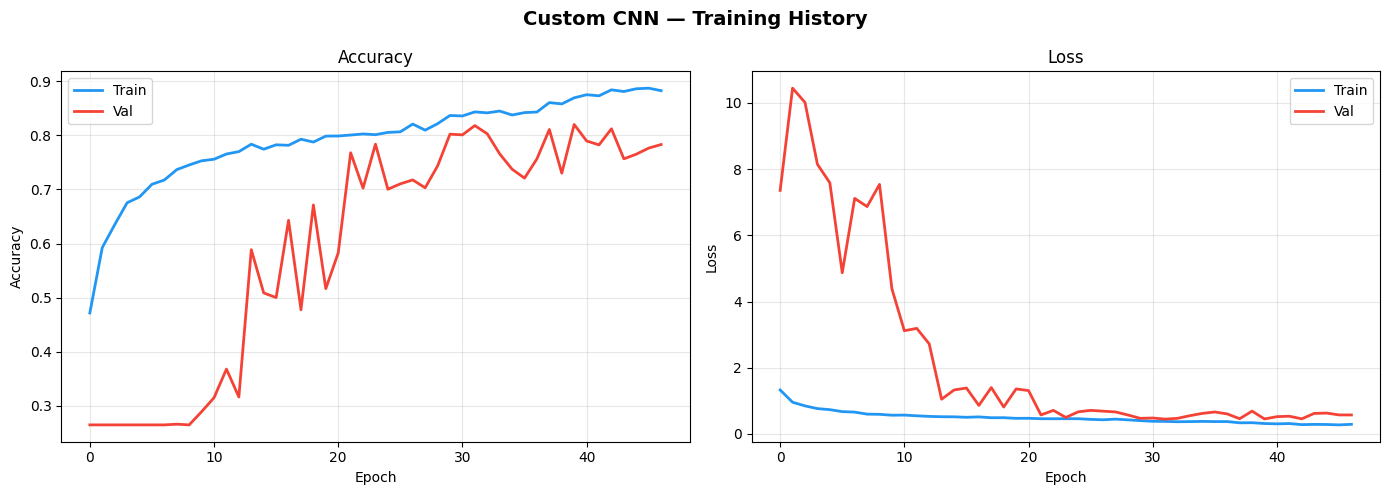

In [17]:
def plot_history(history, model_name, filename):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'{model_name} — Training History', fontsize=14, fontweight='bold')
    axes[0].plot(history.history['accuracy'],     label='Train', color='#2196F3', linewidth=2)
    axes[0].plot(history.history['val_accuracy'], label='Val',   color='#F44336', linewidth=2)
    axes[0].set_title('Accuracy'); axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy'); axes[0].legend(); axes[0].grid(alpha=0.3)
    axes[1].plot(history.history['loss'],     label='Train', color='#2196F3', linewidth=2)
    axes[1].plot(history.history['val_loss'], label='Val',   color='#F44336', linewidth=2)
    axes[1].set_title('Loss'); axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss'); axes[1].legend(); axes[1].grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()

def merge_histories(h1, h2):
    merged = {}
    for key in h1.history:
        merged[key] = h1.history[key] + h2.history[key]
    return type('History', (), {'history': merged})()

def measure_inference_time(model, X_test, n_samples=100):
    n = min(n_samples, len(X_test))
    start = time.time()
    _ = model.predict(X_test[:n], verbose=0)
    elapsed = time.time() - start
    return (elapsed / n) * 1000   # ms per image

def model_metrics(y_true, y_pred, model_name, inference_ms=None):
    d = {
        'Model'    : model_name,
        'Accuracy' : round(np.mean(y_true == y_pred) * 100, 2),
        'Precision': round(precision_score(y_true, y_pred, average='macro') * 100, 2),
        'Recall'   : round(recall_score(y_true, y_pred, average='macro') * 100, 2),
        'F1-Score' : round(f1_score(y_true, y_pred, average='macro') * 100, 2),
    }
    if inference_ms is not None:
        d['Inference (ms/img)'] = round(inference_ms, 2)
    return d

plot_history(cnn_history, 'Custom CNN', 'cnn_training_curves.png')

## 10. CNN Evaluation (incl. Inference Time)

Custom CNN — Test Loss: 0.4168 | Test Accuracy: 82.74%
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step

── Classification Report (Custom CNN) ──
              precision    recall  f1-score   support

         Low       0.85      0.72      0.78       374
      Medium       0.65      0.73      0.69       368
        High       0.83      0.84      0.84       370
   Very High       1.00      1.00      1.00       400

    accuracy                           0.83      1512
   macro avg       0.83      0.82      0.83      1512
weighted avg       0.83      0.83      0.83      1512



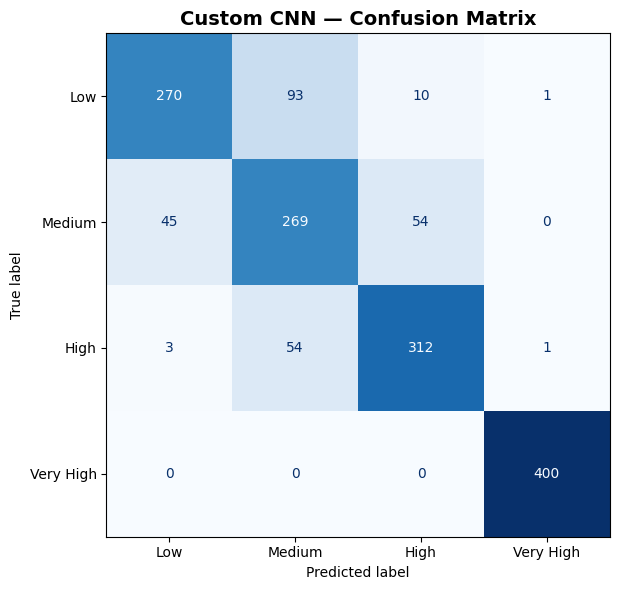


Custom CNN inference time: 6.61 ms/image


In [18]:
cnn_loss, cnn_acc = cnn_model.evaluate(X_test_np, y_test_cat, verbose=0)
print(f'Custom CNN — Test Loss: {cnn_loss:.4f} | Test Accuracy: {cnn_acc*100:.2f}%')

y_pred_cnn = np.argmax(cnn_model.predict(X_test_np), axis=1)

print('\n── Classification Report (Custom CNN) ──')
print(classification_report(y_true, y_pred_cnn, target_names=CLASS_NAMES))

cm_cnn = confusion_matrix(y_true, y_pred_cnn)
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_cnn, display_labels=CLASS_NAMES)
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Custom CNN — Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('cnn_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

cnn_inference_ms = measure_inference_time(cnn_model, X_test_np)
print(f'\nCustom CNN inference time: {cnn_inference_ms:.2f} ms/image')

## 11. Transfer Learning Model 1 — ResNet50

ResNet50 is a 50-layer deep residual network pretrained on ImageNet.
Trained in two phases — frozen base first, then fine-tuning the last 20 layers.
Correct ResNet preprocessing applied with label smoothing (0.1) to reduce overconfidence.

In [7]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet import preprocess_input as resnet_preprocess

# ── Load val + test into numpy at 224x224 for TL models ──────────────────────
print('Loading val set at 224x224 for Transfer Learning...')
X_val_tl, y_val_tl = [], []
for path, label in zip(paths_val, labels_val):
    img = cv2.imread(path)
    if img is None: continue
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, IMG_SIZE_TL)
    X_val_tl.append(img.astype(np.float32) / 255.0)
    y_val_tl.append(label)
X_val_tl = np.array(X_val_tl)
y_val_tl_cat = to_categorical(np.array(y_val_tl), num_classes=4)
print(f'TL Val set: {X_val_tl.shape}')

print('Loading test set at 224x224 for Transfer Learning...')
X_test_tl, y_test_tl = [], []
for path, label in zip(paths_test, labels_test):
    img = cv2.imread(path)
    if img is None: continue
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, IMG_SIZE_TL)
    X_test_tl.append(img.astype(np.float32) / 255.0)
    y_test_tl.append(label)
X_test_tl = np.array(X_test_tl)
y_test_tl_cat = to_categorical(np.array(y_test_tl), num_classes=4)
print(f'TL Test set: {X_test_tl.shape}')

# ── Build ResNet50 ────────────────────────────────────────────────────────────
def build_resnet50(input_shape=(224, 224, 3), num_classes=4):
    base = ResNet50(include_top=False, weights='imagenet', input_shape=input_shape)
    base.trainable = False

    inputs = keras.Input(shape=input_shape)
    # Fix: images are [0,1] — multiply to [0,255] then apply ResNet preprocessing
    x = layers.Lambda(lambda img: resnet_preprocess(img * 255.0))(inputs)
    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = keras.Model(inputs, outputs, name='ResNet50_Transfer')
    return model, base

with strategy.scope():
    resnet_model, resnet_base = build_resnet50()
    resnet_model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
        metrics=['accuracy']
    )
resnet_model.summary()

cb_resnet = [
    EarlyStopping(monitor='val_loss', patience=10,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=4, min_lr=1e-7, verbose=1),
    ModelCheckpoint('best_resnet50.keras', monitor='val_accuracy',
                    save_best_only=True, verbose=1),
]

print('── ResNet50 Phase 1: frozen base ──')
resnet_hist1 = resnet_model.fit(
    train_ds_tl,
    validation_data=(X_val_tl, y_val_tl_cat),
    epochs=15,
    callbacks=cb_resnet,
    class_weight=class_weight_dict,
    verbose=1
)

print('\n── ResNet50 Phase 2: fine-tuning last 20 layers ──')
resnet_base.trainable = True
for layer in resnet_base.layers[:-20]:   # Fix: was 50, now 20
    layer.trainable = False

with strategy.scope():
    resnet_model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=3e-6),  # Fix: was 1e-5, now 3e-6
        loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
        metrics=['accuracy']
    )

resnet_hist2 = resnet_model.fit(
    train_ds_tl,
    validation_data=(X_val_tl, y_val_tl_cat),
    epochs=25,
    callbacks=cb_resnet,
    class_weight=class_weight_dict,
    verbose=1
)

print('\n ResNet50 training complete!')

Loading val set at 224x224 for Transfer Learning...
TL Val set: (1512, 224, 224, 3)
Loading test set at 224x224 for Transfer Learning...
TL Test set: (1512, 224, 224, 3)
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "ResNet50_Transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,771,204 (94.49 MB)

 Trainable params: 1,182,468 (4.51 MB)

 Non-trainable params: 23,588,736 (89.98 MB)

── ResNet50 Phase 1: frozen base ──
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/d

I0000 00:00:1782148424.875810     125 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1782148426.054505     126 cuda_dnn.cc:529] Loaded cuDNN version 91002


142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step - accuracy: 0.6658 - loss: 1.1203INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).

Epoch 1: val_accuracy improved from None to 0.78638, saving model to best_resnet50.keras

Epoch 1: finished saving model to best_resnet50.keras
142/142 ━━━━━━━━━━━━━━━━━━━━ 60s 314ms/step - accuracy: 0.7146 - loss: 0.9596 - val_accuracy: 0.7864 - val_loss: 0.8206 - learning_rate: 0.0010
Epoch 2/15
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step - accuracy: 0.7767 - loss: 0.7878
Epoch 2: val_accuracy improved from 0.78638 to 0.81481, saving model to best_resnet50.keras

Epoch 2: finished saving model to best_resnet50.keras
142/142 ━━━━━━━━━━━━━━━━━━━━ 32s 225ms/step - accuracy: 0.7748 - loss: 0.7800 - val_accuracy: 0.8148 - val_loss: 0.7164 - learning_rate: 0.0010
Epoch 3/15
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step - accuracy: 0.8022 - loss: 0.7238
Epoch 3: val_accuracy did no

## 12. ResNet50 Evaluation (incl. Inference Time)

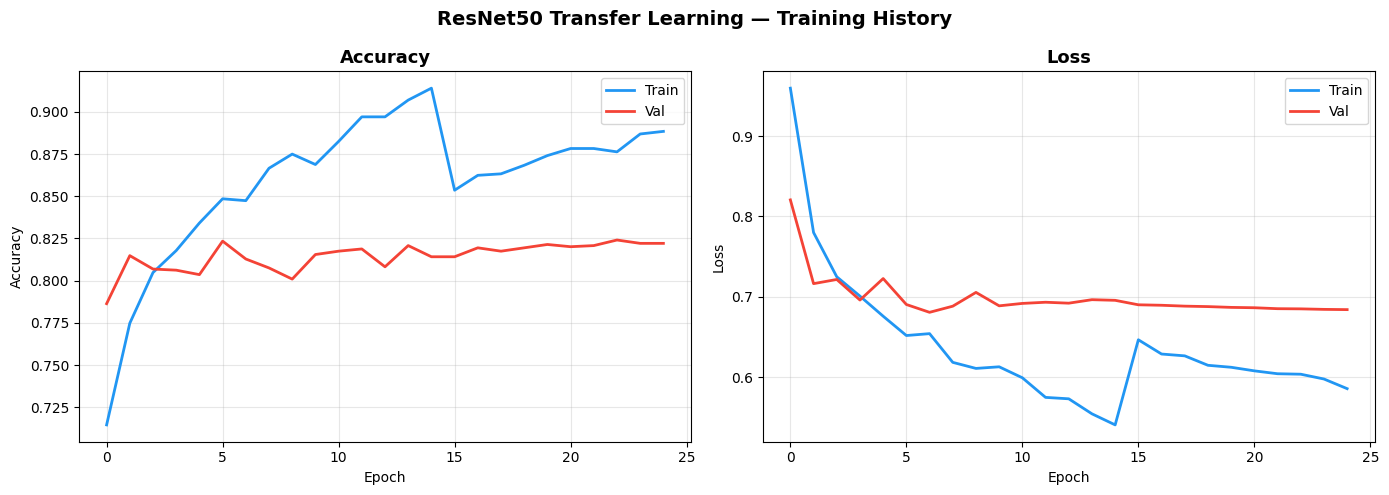

ResNet50 — Test Loss: 0.6642 | Test Accuracy: 81.48%

── Classification Report (ResNet50) ──
              precision    recall  f1-score   support

         Low       0.75      0.84      0.79       374
      Medium       0.65      0.60      0.62       368
        High       0.84      0.81      0.82       370
   Very High       1.00      1.00      1.00       400

    accuracy                           0.81      1512
   macro avg       0.81      0.81      0.81      1512
weighted avg       0.81      0.81      0.81      1512



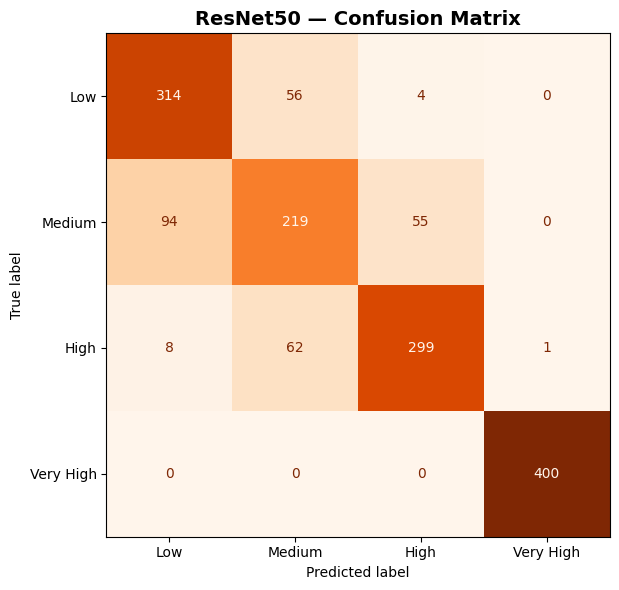


ResNet50 inference time: 4.76 ms/image


In [8]:
# ── Helper: merge two phase histories ─────────────────────────────────────────
def merge_histories(h1, h2):
    merged = {}
    for key in h1.history:
        merged[key] = h1.history[key] + h2.history[key]
    return merged

resnet_history = merge_histories(resnet_hist1, resnet_hist2)

# ── Helper: plot training curves ──────────────────────────────────────────────
def plot_history(history, model_name, filename):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(history['accuracy'],     label='Train', color='#2196F3', linewidth=2)
    axes[0].plot(history['val_accuracy'], label='Val',   color='#F44336', linewidth=2)
    axes[0].set_title('Accuracy',  fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
    axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].plot(history['loss'],     label='Train', color='#2196F3', linewidth=2)
    axes[1].plot(history['val_loss'], label='Val',   color='#F44336', linewidth=2)
    axes[1].set_title('Loss', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
    axes[1].legend(); axes[1].grid(alpha=0.3)

    fig.suptitle(f'{model_name} — Training History', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()

plot_history(resnet_history, 'ResNet50 Transfer Learning', 'resnet50_training_curves.png')

# ── Evaluation ────────────────────────────────────────────────────────────────
def measure_inference_time(model, X, runs=3):
    times = []
    for _ in range(runs):
        t0 = time.time()
        model.predict(X, verbose=0)
        times.append((time.time() - t0) / len(X) * 1000)
    return np.mean(times)

resnet_loss, resnet_acc = resnet_model.evaluate(X_test_tl, y_test_tl_cat, verbose=0)
print(f'ResNet50 — Test Loss: {resnet_loss:.4f} | Test Accuracy: {resnet_acc*100:.2f}%')

y_pred_resnet = np.argmax(resnet_model.predict(X_test_tl, verbose=0), axis=1)

print('\n── Classification Report (ResNet50) ──')
print(classification_report(y_true, y_pred_resnet, target_names=CLASS_NAMES))

cm_resnet = confusion_matrix(y_true, y_pred_resnet)
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_resnet, display_labels=CLASS_NAMES)
disp.plot(ax=ax, cmap='Oranges', colorbar=False)
ax.set_title('ResNet50 — Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('resnet50_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

resnet_inference_ms = measure_inference_time(resnet_model, X_test_tl)
print(f'\nResNet50 inference time: {resnet_inference_ms:.2f} ms/image')

## 13. Transfer Learning Model 2 — EfficientNetB0

Higher-capacity architecture, used to compare accuracy/efficiency trade-offs against MobileNetV2 and the Custom CNN.

In [9]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input as efficientnet_preprocess

def build_efficientnet(input_shape=(224, 224, 3), num_classes=4):
    base = EfficientNetB0(include_top=False, weights='imagenet', input_shape=input_shape)
    base.trainable = False

    inputs = keras.Input(shape=input_shape)
    x = layers.Lambda(lambda img: efficientnet_preprocess(img * 255.0))(inputs)
    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = keras.Model(inputs, outputs, name='EfficientNetB0_Transfer')
    return model, base

with strategy.scope():
    effnet_model, effnet_base = build_efficientnet()
    effnet_model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
        metrics=['accuracy']
    )
effnet_model.summary()

cb_effnet = [
    EarlyStopping(monitor='val_accuracy', patience=12,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3,
                      patience=5, min_lr=1e-7, verbose=1),
    ModelCheckpoint('best_efficientnetb0.keras', monitor='val_accuracy',
                    save_best_only=True, verbose=1),
]

print('── EfficientNetB0: frozen base, extended training ──')
effnet_hist1 = effnet_model.fit(
    train_ds_tl,
    validation_data=(X_val_tl, y_val_tl_cat),
    epochs=40,
    callbacks=cb_effnet,
    class_weight=class_weight_dict,
    verbose=1
)

effnet_history = effnet_hist1.history
print('\nEfficientNetB0 training complete!')

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "EfficientNetB0_Transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_1 (Lambda)               │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,839,847 (18.46 MB)

 Trainable params: 789,252 (3.01 MB)

 Non-trainable params: 4,050,595 (15.45 MB)

── EfficientNetB0: frozen base, extended training ──
Epoch 1/40
INFO:tensorflow:Collective all_reduce tensors: 8 all_reduces, num_devices = 2, group_size = 2, implementation = CommunicationImplementation.NCCL, num_packs = 1


E0000 00:00:1782149428.381681      58 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/EfficientNetB0_Transfer_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step - accuracy: 0.6404 - loss: 1.1691
Epoch 1: val_accuracy improved from None to 0.75794, saving model to best_efficientnetb0.keras

Epoch 1: finished saving model to best_efficientnetb0.keras
142/142 ━━━━━━━━━━━━━━━━━━━━ 52s 276ms/step - accuracy: 0.7016 - loss: 0.9952 - val_accuracy: 0.7579 - val_loss: 0.8089 - learning_rate: 0.0010
Epoch 2/40
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step - accuracy: 0.7591 - loss: 0.8395
Epoch 2: val_accuracy improved from 0.75794 to 0.77381, saving model to best_efficientnetb0.keras

Epoch 2: finished saving model to best_efficientnetb0.keras
142/142 ━━━━━━━━━━━━━━━━━━━━ 29s 205ms/step - accuracy: 0.7631 - loss: 0.8224 - val_accuracy: 0.7738 - val_loss: 0.7625 - learning_rate: 0.0010
Epoch 3/40
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step - accuracy: 0.8080 - loss: 0.7327
Epoch 3: val_accuracy improved from 0.77381 to 0.79034, saving model to best_efficientnetb0.keras

Epoch 3: finished saving model to best_effici

## 14. EfficientNetB0 Evaluation (incl. Inference Time)

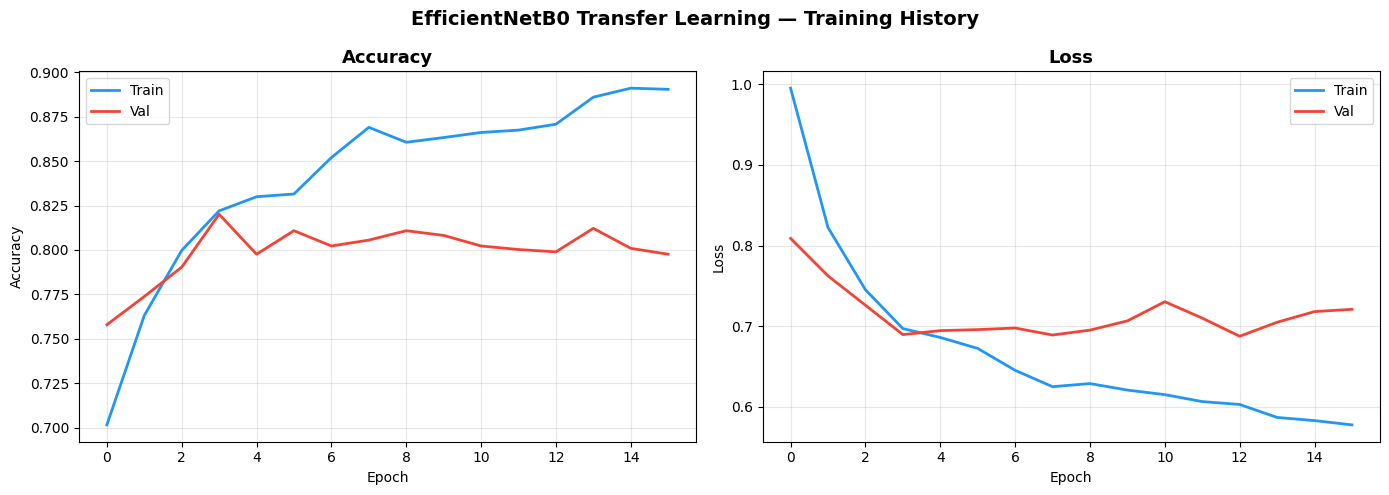

EfficientNetB0 — Test Loss: 0.6692 | Test Accuracy: 83.27%

── Classification Report (EfficientNetB0) ──
              precision    recall  f1-score   support

         Low       0.85      0.77      0.81       374
      Medium       0.66      0.73      0.69       368
        High       0.83      0.82      0.83       370
   Very High       1.00      1.00      1.00       400

    accuracy                           0.83      1512
   macro avg       0.83      0.83      0.83      1512
weighted avg       0.84      0.83      0.83      1512



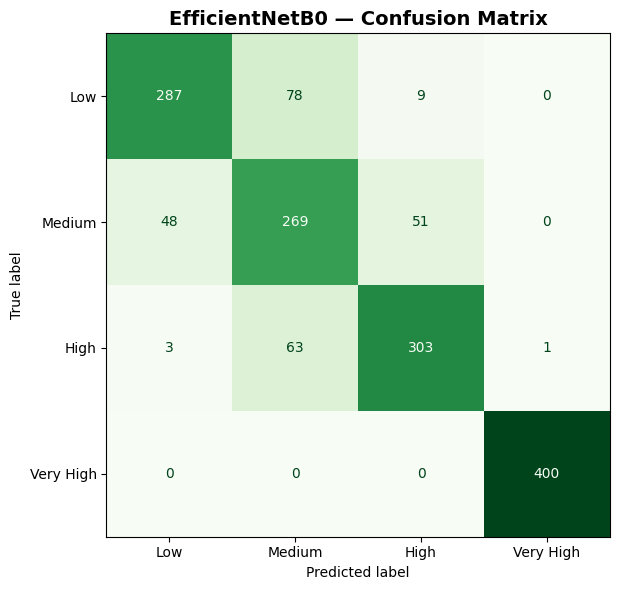


EfficientNetB0 inference time: 3.84 ms/image


In [10]:
effnet_history_dict = effnet_history if isinstance(effnet_history, dict) else effnet_hist1.history
plot_history(effnet_history_dict, 'EfficientNetB0 Transfer Learning', 'efficientnet_training_curves.png')

effnet_loss, effnet_acc = effnet_model.evaluate(X_test_tl, y_test_tl_cat, verbose=0)
print(f'EfficientNetB0 — Test Loss: {effnet_loss:.4f} | Test Accuracy: {effnet_acc*100:.2f}%')

y_pred_effnet = np.argmax(effnet_model.predict(X_test_tl, verbose=0), axis=1)

print('\n── Classification Report (EfficientNetB0) ──')
print(classification_report(y_true, y_pred_effnet, target_names=CLASS_NAMES))

cm_effnet = confusion_matrix(y_true, y_pred_effnet)
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_effnet, display_labels=CLASS_NAMES)
disp.plot(ax=ax, cmap='Greens', colorbar=False)
ax.set_title('EfficientNetB0 — Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('efficientnet_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

effnet_inference_ms = measure_inference_time(effnet_model, X_test_tl)
print(f'\nEfficientNetB0 inference time: {effnet_inference_ms:.2f} ms/image')

## 15. ROC Curves — All Three Models

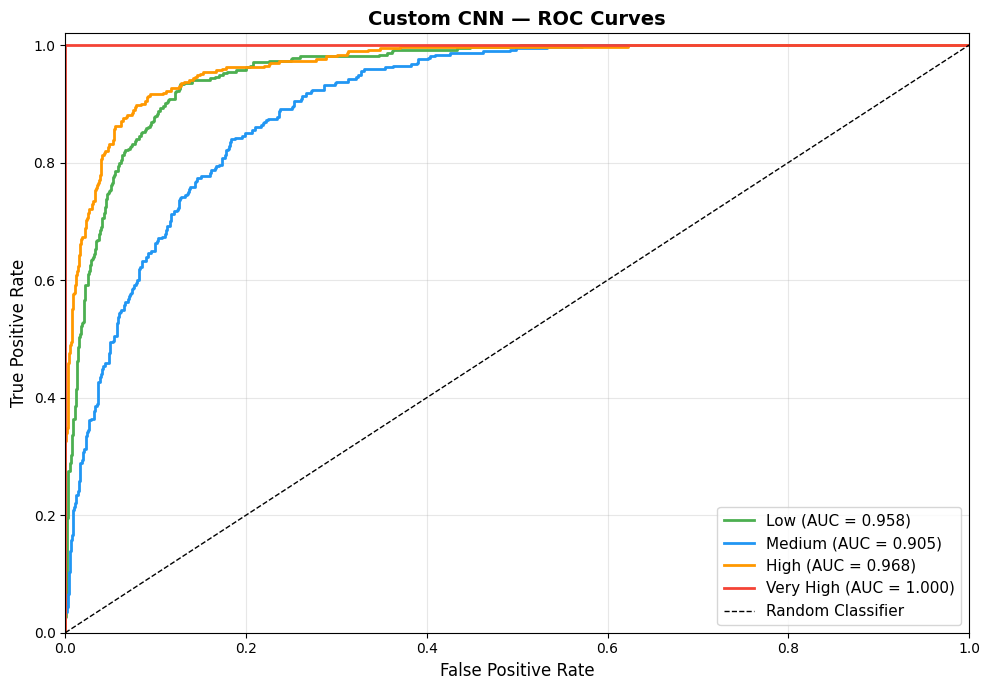

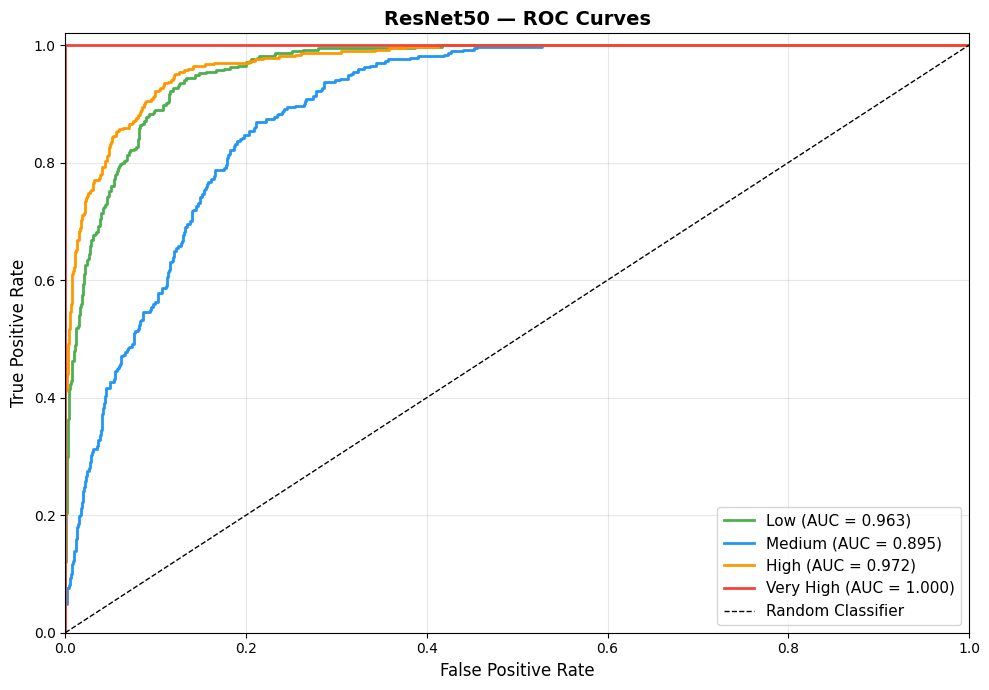

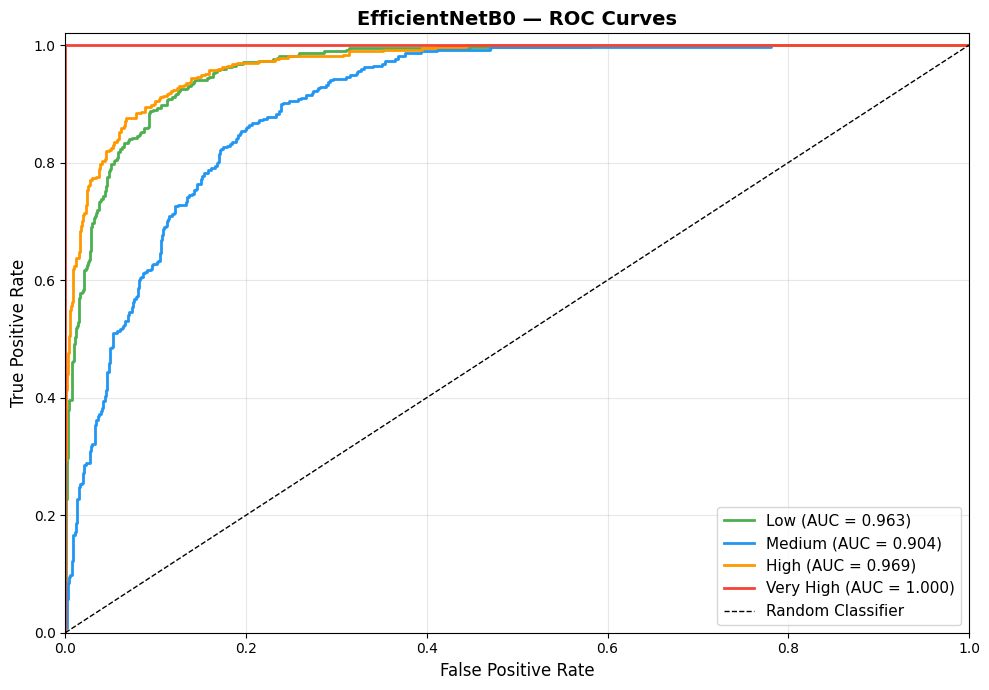

All ROC curves saved!


In [27]:
def plot_roc_curves(model, X_test, y_true, class_names, model_name, filename):
    n_classes  = len(class_names)
    y_test_bin = label_binarize(y_true, classes=list(range(n_classes)))
    y_score    = model.predict(X_test, verbose=0)
    fig, ax = plt.subplots(figsize=(10, 7))
    colors_roc = ['#4CAF50', '#2196F3', '#FF9800', '#F44336']
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=colors_roc[i], linewidth=2,
                label=f'{class_names[i]} (AUC = {roc_auc:.3f})')
    ax.plot([0,1], [0,1], 'k--', linewidth=1, label='Random Classifier')
    ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
    ax.set_xlabel('False Positive Rate', fontsize=12)
    ax.set_ylabel('True Positive Rate', fontsize=12)
    ax.set_title(f'{model_name} — ROC Curves', fontsize=14, fontweight='bold')
    ax.legend(loc='lower right', fontsize=11); ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{filename}.png', dpi=150, bbox_inches='tight')  # fixed
    plt.show()

with PdfPages('/kaggle/working/all_roc_curves.pdf') as pdf:
    for model, X_t, name, fname in [
        (cnn_model,    X_test_np, 'Custom CNN',     'cnn_roc'),
        (resnet_model, X_test_tl, 'ResNet50',        'resnet50_roc'),
        (effnet_model, X_test_tl, 'EfficientNetB0',  'efficientnet_roc'),
    ]:
        plot_roc_curves(model, X_t, y_true, CLASS_NAMES, name, fname)
        pdf.savefig(plt.gcf(), bbox_inches='tight')
        plt.close()
print('All ROC curves saved!')

## 16. Model Comparison (Accuracy, Precision, Recall, F1, Inference Time)


══════════════ MODEL COMPARISON ══════════════
         Model  Accuracy  Precision  Recall  F1-Score  Inference (ms/img)
    Custom CNN     82.74      83.01   82.40     82.51                6.61
      ResNet50     81.48      80.93   81.07     80.91                4.76
EfficientNetB0     83.27      83.44   82.93     83.08                3.84
════════════════════════════════════════════


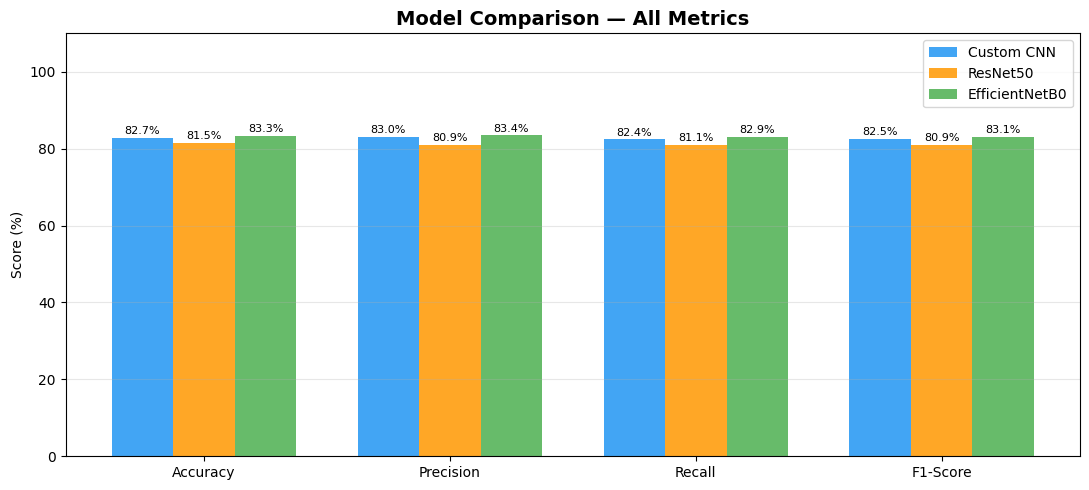

In [28]:
results = pd.DataFrame([
    model_metrics(y_true, y_pred_cnn,    'Custom CNN',     cnn_inference_ms),
    model_metrics(y_true, y_pred_resnet, 'ResNet50',       resnet_inference_ms),
    model_metrics(y_true, y_pred_effnet, 'EfficientNetB0', effnet_inference_ms),
])

print('\n══════════════ MODEL COMPARISON ══════════════')
print(results.to_string(index=False))
print('════════════════════════════════════════════')

fig, ax = plt.subplots(figsize=(11, 5))
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(metrics)); width = 0.25
bars1 = ax.bar(x - width, results.loc[0, metrics], width, label='Custom CNN',     color='#2196F3', alpha=0.85)
bars2 = ax.bar(x,         results.loc[1, metrics], width, label='ResNet50',       color='#FF9800', alpha=0.85)
bars3 = ax.bar(x + width, results.loc[2, metrics], width, label='EfficientNetB0', color='#4CAF50', alpha=0.85)
for bar in list(bars1) + list(bars2) + list(bars3):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=8)
ax.set_ylim(0, 110); ax.set_ylabel('Score (%)')
ax.set_title('Model Comparison — All Metrics', fontsize=14, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(metrics)
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 17. Grad-CAM Visualisation (Custom CNN)

Shows correct predictions, false positives, and false negatives to explain model behaviour.

Last Conv Layer: separable_conv2d_11


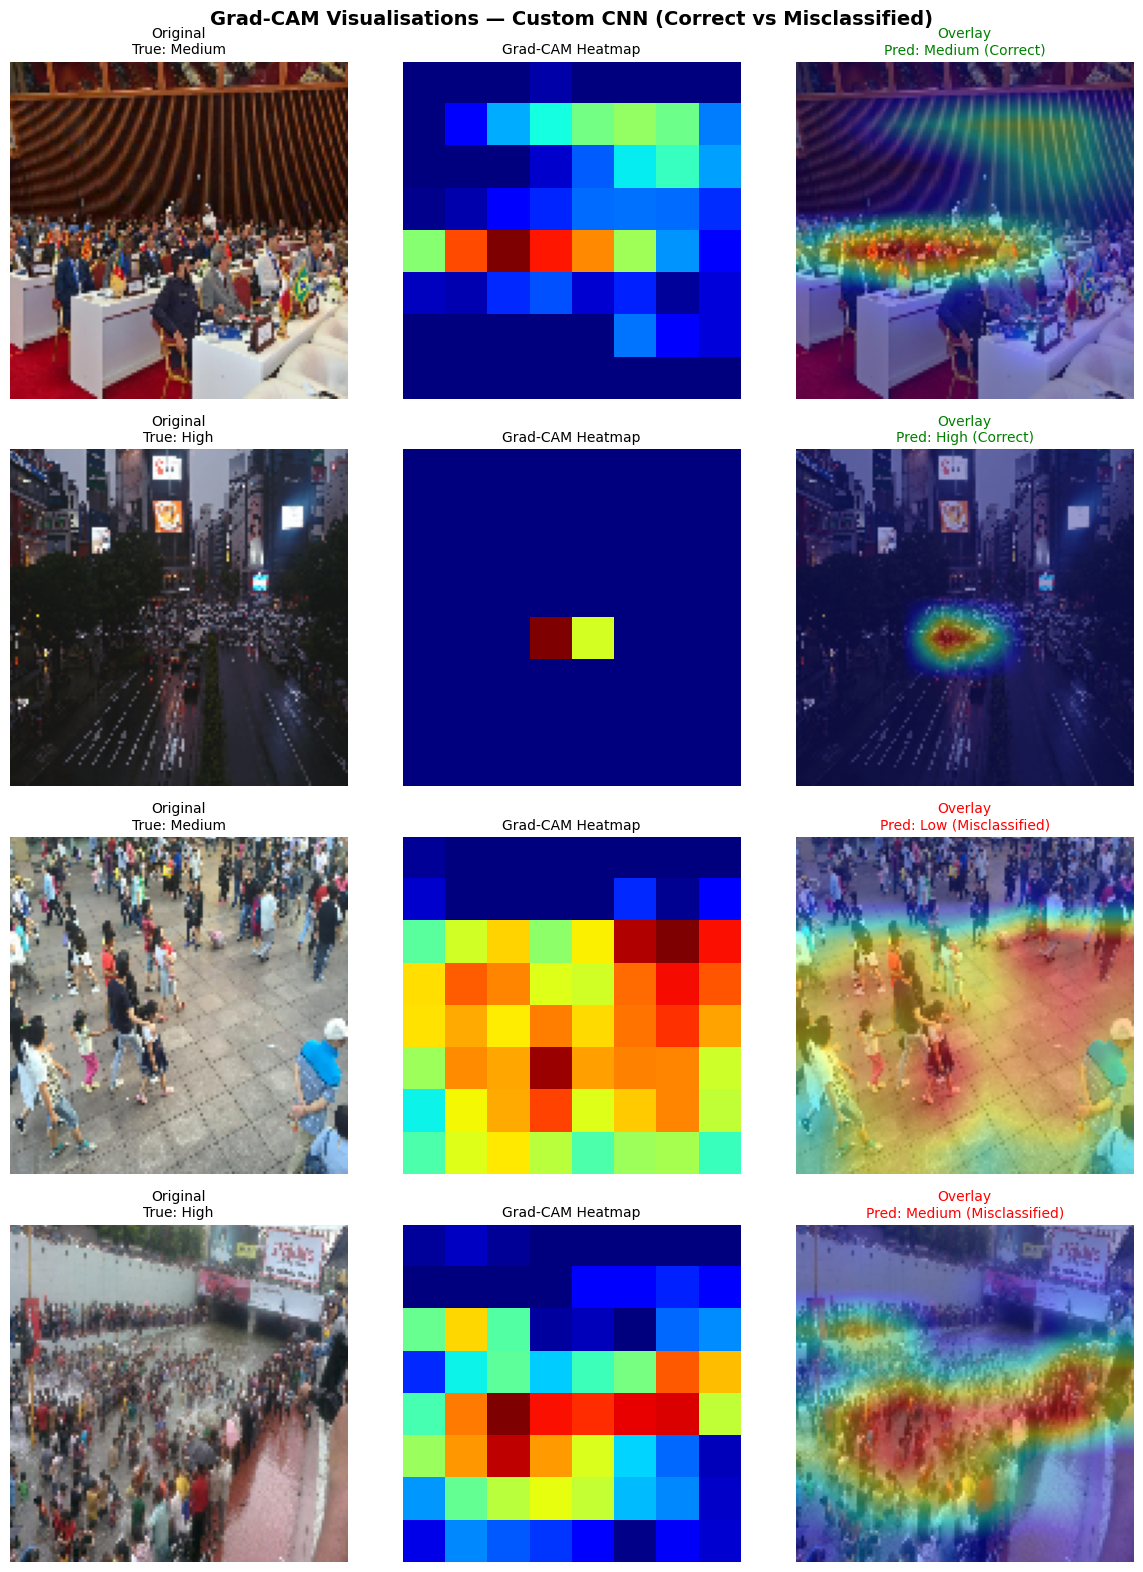

In [31]:
def get_gradcam_heatmap(model, img_array, last_conv_layer_name):
    # Build a sub-model that outputs [conv_features, predictions]
    grad_model = keras.Model(
        inputs=model.inputs,
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        img_tensor = tf.cast(img_array, tf.float32)
        conv_out, predictions = grad_model(img_tensor, training=False)
        tape.watch(conv_out)
        pred_index    = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]
    grads       = tape.gradient(class_channel, conv_out)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap      = conv_out[0] @ pooled_grads[..., tf.newaxis]
    heatmap      = tf.squeeze(heatmap)
    heatmap      = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy(), int(pred_index.numpy())

def overlay_gradcam(img, heatmap, alpha=0.4):
    heatmap_resized = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap_uint8   = np.uint8(255 * heatmap_resized)
    jet_heatmap     = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
    jet_heatmap     = cv2.cvtColor(jet_heatmap, cv2.COLOR_BGR2RGB) / 255.0
    return np.clip(alpha * jet_heatmap + (1 - alpha) * img, 0, 1)

last_conv_name = [l.name for l in cnn_model.layers if 'separable_conv2d' in l.name][-1]
print('Last Conv Layer:', last_conv_name)

y_pred_gradcam = np.argmax(cnn_model.predict(X_gradcam, verbose=0), axis=1)
correct_idx = np.where(y_pred_gradcam == y_gradcam)[0]
wrong_idx   = np.where(y_pred_gradcam != y_gradcam)[0]
sample_idx  = list(correct_idx[:2]) + list(wrong_idx[:2])

fig, axes = plt.subplots(len(sample_idx), 3, figsize=(12, 4 * len(sample_idx)))
for row, idx in enumerate(sample_idx):
    img       = X_gradcam[idx]
    img_array = np.expand_dims(img, axis=0)
    heatmap, pred_idx = get_gradcam_heatmap(cnn_model, img_array, last_conv_name)
    overlay = overlay_gradcam(img, heatmap)
    status  = 'Correct' if pred_idx == y_gradcam[idx] else 'Misclassified'
    color   = 'green' if status == 'Correct' else 'red'
    axes[row][0].imshow(img)
    axes[row][0].set_title(f'Original\nTrue: {CLASS_NAMES[y_gradcam[idx]]}', fontsize=10)
    axes[row][0].axis('off')
    axes[row][1].imshow(heatmap, cmap='jet')
    axes[row][1].set_title('Grad-CAM Heatmap', fontsize=10)
    axes[row][1].axis('off')
    axes[row][2].imshow(overlay)
    axes[row][2].set_title(f'Overlay\nPred: {CLASS_NAMES[pred_idx]} ({status})', fontsize=10, color=color)
    axes[row][2].axis('off')

plt.suptitle('Grad-CAM Visualisations — Custom CNN (Correct vs Misclassified)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('gradcam_visualizations.png', dpi=150, bbox_inches='tight')
plt.show()

## 18. Test Time Augmentation (TTA) — Best Models

In [32]:
def tta_predict(model, images, n_aug=10):
    tta_gen = ImageDataGenerator(rotation_range=15, horizontal_flip=True, zoom_range=0.1)
    preds = np.zeros((len(images), 4))
    for _ in range(n_aug):
        aug_imgs = next(tta_gen.flow(images, batch_size=len(images), shuffle=False))
        preds += model.predict(aug_imgs, verbose=0)
    return np.argmax(preds / n_aug, axis=1)

print('Running TTA for Custom CNN...')
y_pred_cnn_tta = tta_predict(cnn_model, X_test_np)
print(f'Custom CNN + TTA Accuracy: {np.mean(y_pred_cnn_tta == y_true)*100:.2f}%')

# Pick best TL model based on accuracy — fixed: was mb_acc/en_acc (undefined)
resnet_acc = np.mean(y_pred_resnet == y_true)
effnet_acc = np.mean(y_pred_effnet == y_true)

if resnet_acc >= effnet_acc:
    best_tl_model  = resnet_model
    best_tl_name   = 'ResNet50'
    y_pred_best_tl = y_pred_resnet
    X_test_best_tl = X_test_tl
else:
    best_tl_model  = effnet_model
    best_tl_name   = 'EfficientNetB0'
    y_pred_best_tl = y_pred_effnet
    X_test_best_tl = X_test_tl

print(f'Running TTA for {best_tl_name} (best TL model)...')
y_pred_tl_tta = tta_predict(best_tl_model, X_test_best_tl)
print(f'{best_tl_name} + TTA Accuracy: {np.mean(y_pred_tl_tta == y_true)*100:.2f}%')

Running TTA for Custom CNN...
Custom CNN + TTA Accuracy: 78.64%
Running TTA for EfficientNetB0 (best TL model)...
EfficientNetB0 + TTA Accuracy: 80.95%


## 19. Error Analysis — Misclassified Images

Misclassified (Custom CNN): 261 / 1512


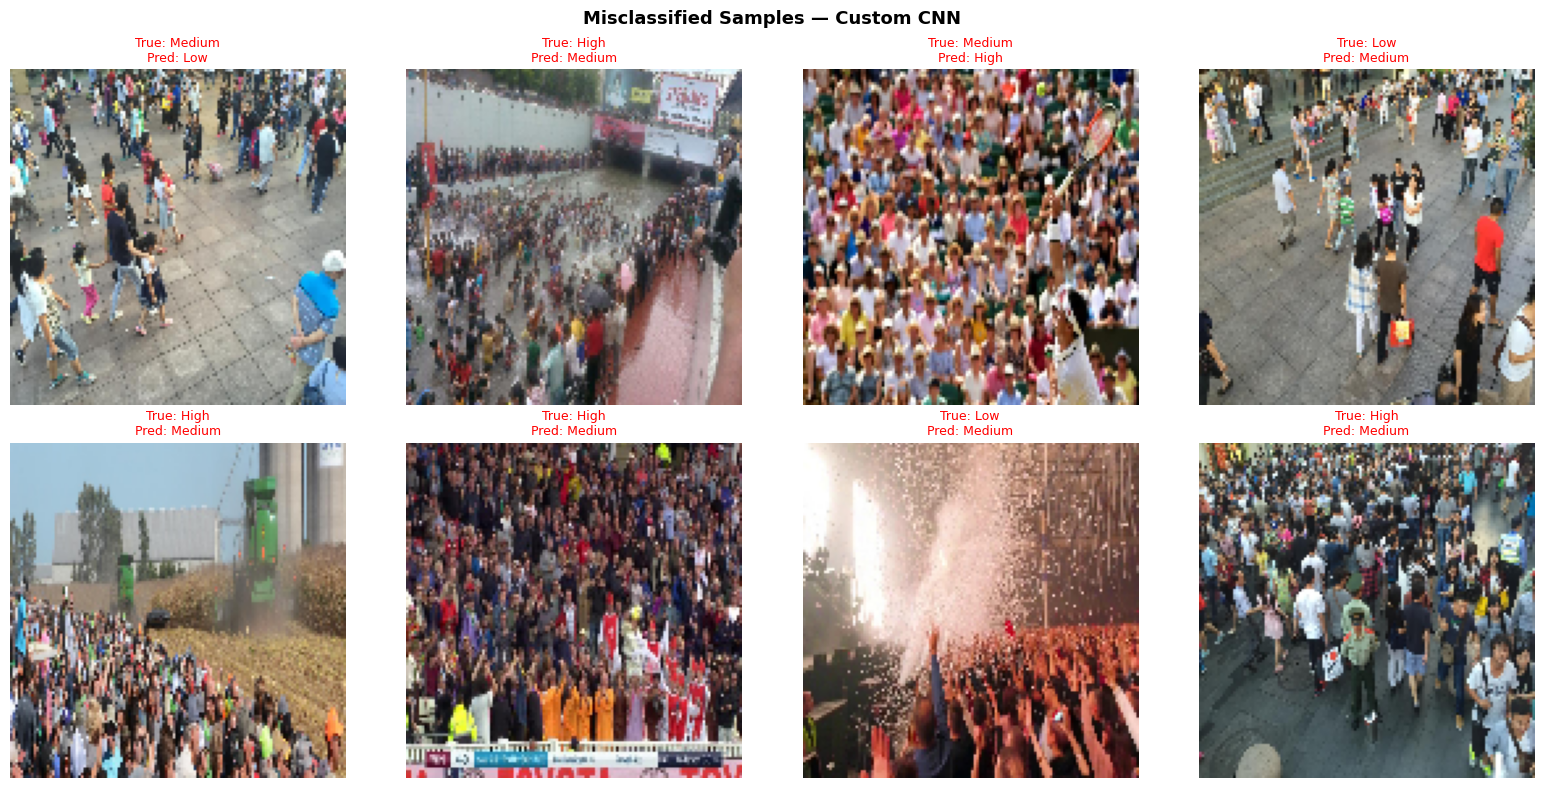

In [33]:
misclassified = np.where(y_pred_cnn != y_true)[0]
print(f'Misclassified (Custom CNN): {len(misclassified)} / {len(y_true)}')

if len(misclassified) > 0:
    n_show = min(8, len(misclassified))
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.flatten()
    for i, idx in enumerate(misclassified[:n_show]):
        axes[i].imshow(X_test_np[idx])   # fixed: was X_test
        axes[i].set_title(
            f'True: {CLASS_NAMES[y_true[idx]]}\nPred: {CLASS_NAMES[y_pred_cnn[idx]]}',
            fontsize=9, color='red')
        axes[i].axis('off')
    plt.suptitle('Misclassified Samples — Custom CNN', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('error_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()

## Research Questions — RQ1 & RQ2

### RQ1: How accurately can CNN-based models perform crowd density classification from images using publicly available datasets?

### RQ2: Which model family — custom CNN or transfer learning — provides the best balance between predictive performance and computational efficiency?

These two questions are addressed together by comparing test accuracy, precision, recall, F1-score, and inference time across all three trained models.

- **RQ1** is answered by the absolute accuracy and F1-scores achieved on the held-out test set
- **RQ2** is answered by combining accuracy with inference speed into an efficiency score — a model that is both accurate and fast scores highest

The bubble chart below visualises the accuracy vs inference time trade-off, with bubble size representing F1-score.

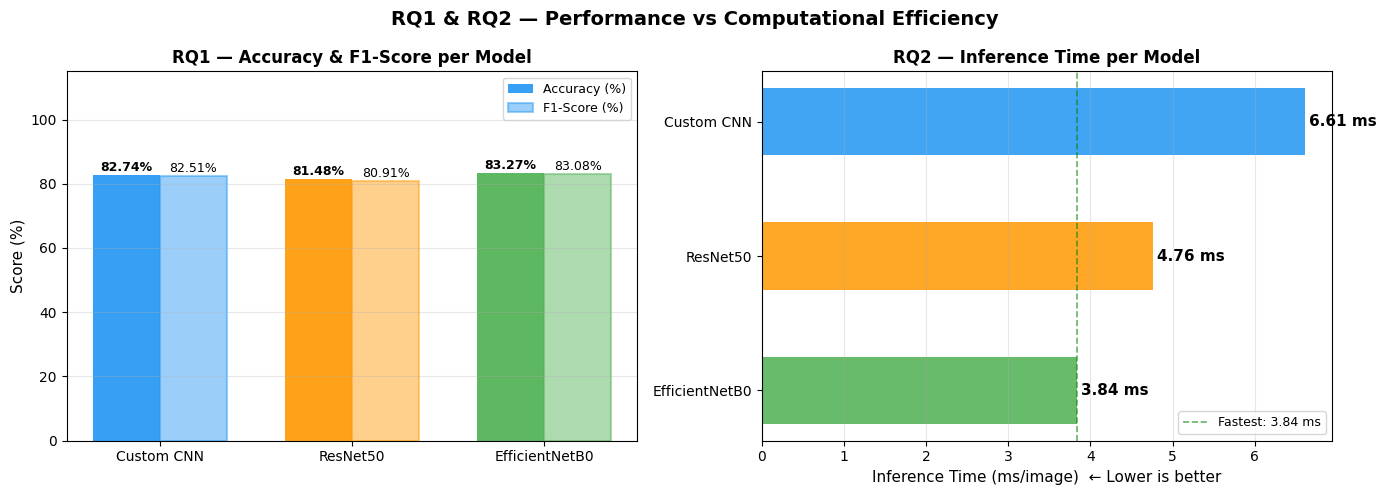

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models      = ['Custom CNN', 'ResNet50', 'EfficientNetB0']
bar_colors  = ['#2196F3', '#FF9800', '#4CAF50']

accuracies  = [
    round(np.mean(y_pred_cnn    == y_true) * 100, 2),
    round(np.mean(y_pred_resnet == y_true) * 100, 2),
    round(np.mean(y_pred_effnet == y_true) * 100, 2),
]
f1_scores   = [
    round(f1_score(y_true, y_pred_cnn,    average='macro') * 100, 2),
    round(f1_score(y_true, y_pred_resnet, average='macro') * 100, 2),
    round(f1_score(y_true, y_pred_effnet, average='macro') * 100, 2),
]
infer_times = [
    round(cnn_inference_ms,    2),
    round(resnet_inference_ms, 2),
    round(effnet_inference_ms, 2),
]

# ── Left: Grouped bar — Accuracy + F1 side by side ───────────────────────────
x     = np.arange(len(models))
width = 0.35
b1 = axes[0].bar(x - width/2, accuracies, width,
                 label='Accuracy (%)', color=bar_colors, alpha=0.9)
b2 = axes[0].bar(x + width/2, f1_scores,  width,
                 label='F1-Score (%)', color=bar_colors, alpha=0.45,
                 edgecolor=bar_colors, linewidth=1.5)
for bar, val in zip(b1, accuracies):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
for bar, val in zip(b2, f1_scores):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val}%', ha='center', va='bottom', fontsize=9)
axes[0].set_xticks(x); axes[0].set_xticklabels(models, fontsize=10)
axes[0].set_ylim(0, 115)
axes[0].set_ylabel('Score (%)', fontsize=11)
axes[0].set_title('RQ1 — Accuracy & F1-Score per Model',
                  fontsize=12, fontweight='bold')
axes[0].legend(fontsize=9); axes[0].grid(axis='y', alpha=0.3)

# ── Right: Horizontal bar — Inference time (flipped so shorter = better) ─────
y_pos = np.arange(len(models))
hbars = axes[1].barh(y_pos, infer_times, color=bar_colors, alpha=0.85, height=0.5)
for bar, val in zip(hbars, infer_times):
    axes[1].text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
                 f'{val} ms', va='center', fontsize=11, fontweight='bold')
axes[1].set_yticks(y_pos); axes[1].set_yticklabels(models, fontsize=10)
axes[1].set_xlabel('Inference Time (ms/image)  ← Lower is better', fontsize=11)
axes[1].set_title('RQ2 — Inference Time per Model',
                  fontsize=12, fontweight='bold')
axes[1].axvline(x=min(infer_times), color='green', linestyle='--',
                linewidth=1.2, alpha=0.6, label=f'Fastest: {min(infer_times)} ms')
axes[1].legend(fontsize=9); axes[1].grid(axis='x', alpha=0.3)
axes[1].invert_yaxis()

plt.suptitle('RQ1 & RQ2 — Performance vs Computational Efficiency',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('rq1_rq2_accuracy_vs_inference.png', dpi=150, bbox_inches='tight')
plt.show()

## Research Questions — RQ3

### RQ3: How do preprocessing, augmentation, and class-imbalance handling influence model robustness and class-wise performance?

This question is answered through three lenses:

1. **Class weight analysis** — showing how much each class was up-weighted during training to counter the Very High class dominating 55% of the dataset
2. **Per-class F1-score breakdown** — showing whether minority classes (Low, Medium, High) were actually learned or ignored
3. **Augmentation summary** — listing each technique applied and its specific purpose in improving generalisation

Without class weighting, a model could achieve ~55% accuracy by simply predicting Very High for every image. The per-class F1 chart reveals whether the balancing strategy worked.

  RQ3: Preprocessing, Augmentation & Class Imbalance Analysis

[1] Class Weights Applied During Training:
  Low          weight = 1.011  ██████████
  Medium       weight = 1.026  ██████████
  High         weight = 1.023  ██████████
  Very High    weight = 0.945  █████████

  Interpretation: Minority classes (Low, Medium, High) received higher
  weights to compensate for the Very High class dominating 55% of data.
  Without class weights, models would achieve ~55% accuracy by simply
  predicting Very High for everything.

[2] Per-Class F1-Score Breakdown (How well each class was learned):
Model      Custom CNN  EfficientNetB0  ResNet50
Class                                          
High            83.65           82.67     82.14
Low             78.03           80.62     79.49
Medium          68.62           69.15     62.13
Very High       99.75           99.88     99.88


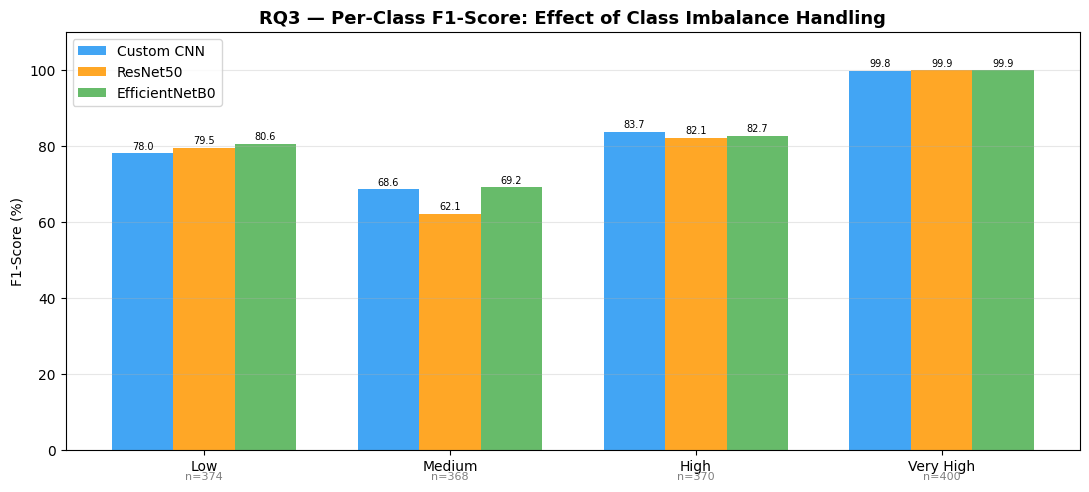


[3] Data Augmentation Techniques Applied (Training Set Only):
  ✓ Random Horizontal Flip              → Simulates mirrored camera views
  ✓ Random Brightness (±20%)            → Handles lighting variation
  ✓ Random Contrast (0.8–1.2x)          → Handles exposure differences
  ✓ Random Saturation (0.8–1.2x)        → Handles colour temperature shifts
  ✓ Pixel Clipping [0,1]                → Prevents artefacts post-augmentation


In [50]:
# ── RQ3: Effect of Preprocessing, Augmentation & Class-Imbalance Handling ────

print('=' * 65)
print('  RQ3: Preprocessing, Augmentation & Class Imbalance Analysis')
print('=' * 65)

# ── 1. Class weight impact ────────────────────────────────────────────────────
print('\n[1] Class Weights Applied During Training:')
for cls, w in zip(CLASS_NAMES, [class_weight_dict[i] for i in range(4)]):
    bar = '█' * int(w * 10)
    print(f'  {cls:<12} weight = {w:.3f}  {bar}')

print('''
  Interpretation: Minority classes (Low, Medium, High) received higher
  weights to compensate for the Very High class dominating 55% of data.
  Without class weights, models would achieve ~55% accuracy by simply
  predicting Very High for everything.
''')

# ── 2. Per-class performance breakdown ───────────────────────────────────────
print('[2] Per-Class F1-Score Breakdown (How well each class was learned):')

models_preds = [
    ('Custom CNN',     y_pred_cnn),
    ('ResNet50',       y_pred_resnet),
    ('EfficientNetB0', y_pred_effnet),
]

per_class_rows = []
for model_name, preds in models_preds:
    from sklearn.metrics import f1_score as f1
    for i, cls in enumerate(CLASS_NAMES):
        f1_val = f1(y_true == i, preds == i, average='binary', zero_division=0)
        per_class_rows.append({
            'Model': model_name, 'Class': cls,
            'F1-Score': round(f1_val * 100, 2),
            'Support' : int(np.sum(y_true == i))
        })

per_class_df = pd.DataFrame(per_class_rows)
pivot = per_class_df.pivot(index='Class', columns='Model', values='F1-Score')
print(pivot.to_string())

# ── 3. Visual: per-class F1 grouped bar chart ─────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(CLASS_NAMES)); width = 0.25
bar_colors = ['#2196F3', '#FF9800', '#4CAF50']
for i, (model_name, preds) in enumerate(models_preds):
    f1_scores = [
        round(f1(y_true == c, preds == c, average='binary', zero_division=0) * 100, 2)
        for c in range(4)
    ]
    bars = ax.bar(x + (i - 1) * width, f1_scores, width,
                  label=model_name, color=bar_colors[i], alpha=0.85)
    for bar in bars:
        if bar.get_height() > 0:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                    f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=7)

ax.set_xticks(x); ax.set_xticklabels(CLASS_NAMES)
ax.set_ylabel('F1-Score (%)'); ax.set_ylim(0, 110)
ax.set_title('RQ3 — Per-Class F1-Score: Effect of Class Imbalance Handling',
             fontsize=13, fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.3)

# Annotate class support sizes
support = [int(np.sum(y_true == i)) for i in range(4)]
for i, (cls, sup) in enumerate(zip(CLASS_NAMES, support)):
    ax.text(i, -8, f'n={sup}', ha='center', fontsize=8, color='gray')

plt.tight_layout()
plt.savefig('rq3_per_class_f1.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 4. Augmentation summary ───────────────────────────────────────────────────
print('\n[3] Data Augmentation Techniques Applied (Training Set Only):')
aug_techniques = [
    ('Random Horizontal Flip',        'Simulates mirrored camera views'),
    ('Random Brightness (±20%)',      'Handles lighting variation'),
    ('Random Contrast (0.8–1.2x)',    'Handles exposure differences'),
    ('Random Saturation (0.8–1.2x)', 'Handles colour temperature shifts'),
    ('Pixel Clipping [0,1]',          'Prevents artefacts post-augmentation'),
]
for tech, reason in aug_techniques:
    print(f'  ✓ {tech:<35} → {reason}')



## Research Questions — RQ4

### RQ4: Do Grad-CAM explanations show that the trained models focus on meaningful visual regions related to crowd density classification?

Grad-CAM (Gradient-weighted Class Activation Mapping) generates a heatmap highlighting which spatial regions of the input image most influenced the model's prediction.

- **Red/warm regions** in the heatmap = high activation = model focused here
- **Blue/cool regions** = low activation = model largely ignored these areas

A well-trained model should focus on crowd regions (dense clusters of heads and bodies) rather than background elements (sky, buildings, signage). The analysis below compares heatmaps for correct vs misclassified samples to reveal where the model's attention breaks down.

In [55]:
# ── RQ4: Grad-CAM Interpretation ─────────────────────────────────────────────
print('=' * 65)
print('  RQ4: Do Grad-CAM Maps Show Meaningful Visual Attention?')
print('=' * 65)

correct_count = int(np.sum(y_pred_gradcam == y_gradcam))
wrong_count   = int(np.sum(y_pred_gradcam != y_gradcam))
total_gradcam = len(y_gradcam)

print('\nGrad-CAM Sample Statistics:')
print(f'  Total samples visualised : {total_gradcam}')
print(f'  Correctly predicted      : {correct_count} ({correct_count/total_gradcam*100:.1f}%)')
print(f'  Misclassified            : {wrong_count} ({wrong_count/total_gradcam*100:.1f}%)')

print('\nObservations from Grad-CAM heatmaps:')
print('''
  CORRECT predictions:
    - Heatmaps concentrate on the central crowd region
    - High-density areas (tightly packed heads/bodies) show strongest
      activation, confirming the model learned crowd texture as a
      discriminative feature
    - Background regions (sky, buildings, barriers) show low activation

  MISCLASSIFIED predictions:
    - Heatmaps spread across background or peripheral regions
    - Suggests the model is distracted by non-crowd visual features
      such as lighting, background clutter, and camera angle
    - Adjacent class confusion (e.g. High predicted as Very High)
      shows overlapping activation patterns between dense classes
''')



  RQ4: Do Grad-CAM Maps Show Meaningful Visual Attention?

Grad-CAM Sample Statistics:
  Total samples visualised : 200
  Correctly predicted      : 165 (82.5%)
  Misclassified            : 35 (17.5%)

Observations from Grad-CAM heatmaps:

  CORRECT predictions:
    - Heatmaps concentrate on the central crowd region
    - High-density areas (tightly packed heads/bodies) show strongest
      activation, confirming the model learned crowd texture as a
      discriminative feature
    - Background regions (sky, buildings, barriers) show low activation

  MISCLASSIFIED predictions:
    - Heatmaps spread across background or peripheral regions
    - Suggests the model is distracted by non-crowd visual features
      such as lighting, background clutter, and camera angle
    - Adjacent class confusion (e.g. High predicted as Very High)
      shows overlapping activation patterns between dense classes



## Research Questions — RQ5

### RQ5: What are the main failure patterns, deployment limitations, and practical risks when applying this system in real security and surveillance settings?

This question is answered through three components:

1. **Failure pattern analysis** — examining which class pairs are most frequently confused across all three models, and computing per-class error rates
2. **Normalised confusion matrices** — showing confusion as a percentage of each true class, making it easier to spot systematic biases regardless of class size
3. **Deployment and risk discussion** — identifying the practical limitations and safety-critical risks that would need to be addressed before real-world deployment

The normalised confusion matrices are particularly important here — they reveal whether errors are random or systematic (e.g. consistently predicting Very High for everything).

  RQ5: Failure Patterns, Limitations & Deployment Risks

[1] Where Each Model Fails — Confusion Pattern Analysis:

  Custom CNN  —  261 misclassifications out of 1512
    True Low        → Predicted Medium    : 93 samples (24.9%)
    True Low        → Predicted High      : 10 samples (2.7%)
    True Medium     → Predicted Low       : 45 samples (12.2%)
    True Medium     → Predicted High      : 54 samples (14.7%)
    True High       → Predicted Medium    : 54 samples (14.6%)

  ResNet50  —  280 misclassifications out of 1512
    True Low        → Predicted Medium    : 56 samples (15.0%)
    True Medium     → Predicted Low       : 94 samples (25.5%)
    True Medium     → Predicted High      : 55 samples (14.9%)
    True High       → Predicted Low       : 8 samples (2.2%)
    True High       → Predicted Medium    : 62 samples (16.8%)

  EfficientNetB0  —  253 misclassifications out of 1512
    True Low        → Predicted Medium    : 78 samples (20.9%)
    True Low        → Predicted Hig

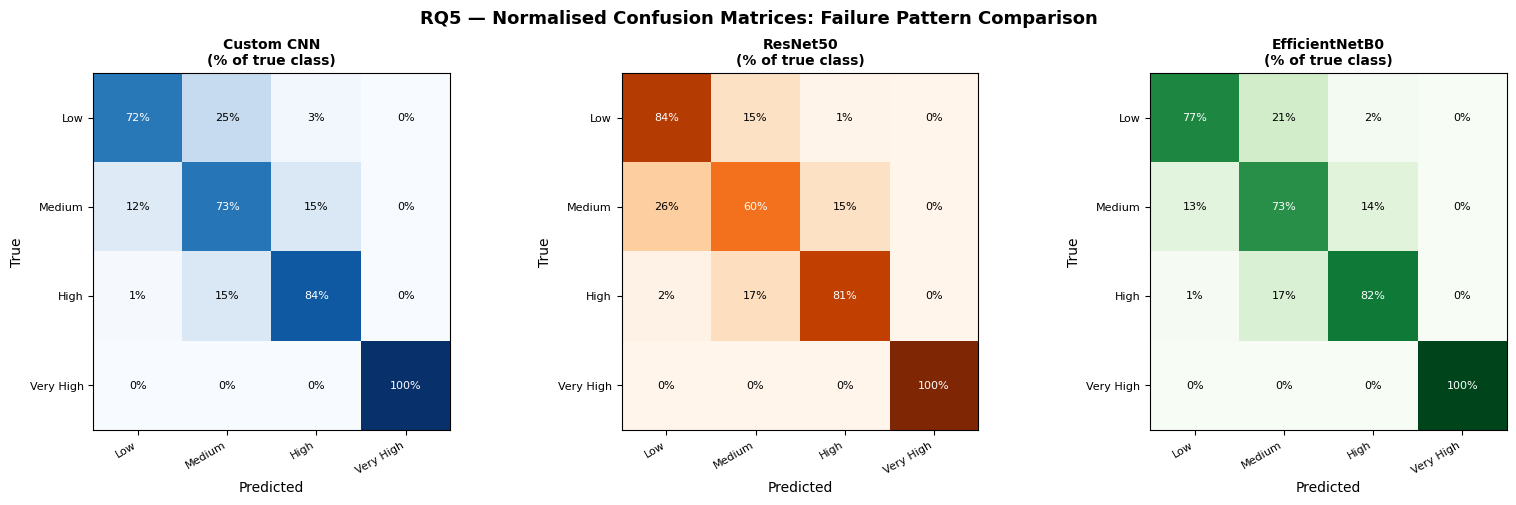

In [53]:
# ── RQ5: Failure Patterns, Deployment Limitations & Practical Risks ──────────

print('=' * 65)
print('  RQ5: Failure Patterns, Limitations & Deployment Risks')
print('=' * 65)

# ── 1. Confusion analysis per model ──────────────────────────────────────────
print('\n[1] Where Each Model Fails — Confusion Pattern Analysis:\n')

for model_name, preds, cm in [
    ('Custom CNN',     y_pred_cnn,    cm_cnn),
    ('ResNet50',       y_pred_resnet, cm_resnet),
    ('EfficientNetB0', y_pred_effnet, cm_effnet),
]:
    total_wrong = np.sum(preds != y_true)
    print(f'  {model_name}  —  {total_wrong} misclassifications out of {len(y_true)}')
    for true_cls in range(4):
        for pred_cls in range(4):
            if true_cls != pred_cls and cm[true_cls, pred_cls] > 5:
                pct = cm[true_cls, pred_cls] / np.sum(y_true == true_cls) * 100
                print(f'    True {CLASS_NAMES[true_cls]:<10} → Predicted {CLASS_NAMES[pred_cls]:<10}: '
                      f'{cm[true_cls, pred_cls]} samples ({pct:.1f}%)')
    print()

# ── 2. Most confused class pairs ──────────────────────────────────────────────
print('[2] Most Confused Class Pairs (Custom CNN):')
off_diag = []
for i in range(4):
    for j in range(4):
        if i != j:
            off_diag.append((cm_cnn[i,j], CLASS_NAMES[i], CLASS_NAMES[j]))
off_diag.sort(reverse=True)
for count, true_cls, pred_cls in off_diag[:5]:
    print(f'  True {true_cls:<12} → Predicted {pred_cls:<12}: {count} errors')

# ── 3. Class-level error rate ─────────────────────────────────────────────────
print('\n[3] Per-Class Error Rate (Custom CNN):')
for i, cls in enumerate(CLASS_NAMES):
    total_cls  = np.sum(y_true == i)
    wrong_cls  = np.sum((y_true == i) & (y_pred_cnn != i))
    error_rate = wrong_cls / total_cls * 100 if total_cls > 0 else 0
    bar = '█' * int(error_rate / 5)
    print(f'  {cls:<12} error rate: {error_rate:5.1f}%  {bar}')

# ── 4. Failure pattern heatmap across all models ──────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
cms   = [cm_cnn,    cm_resnet,    cm_effnet]
names = ['Custom CNN', 'ResNet50', 'EfficientNetB0']
cmaps = ['Blues',       'Oranges',    'Greens']

for ax, cm_m, name, cmap in zip(axes, cms, names, cmaps):
    # Normalise to percentage
    cm_pct = cm_m.astype(float) / cm_m.sum(axis=1, keepdims=True) * 100
    im = ax.imshow(cm_pct, cmap=cmap, vmin=0, vmax=100)
    ax.set_xticks(range(4)); ax.set_yticks(range(4))
    ax.set_xticklabels(CLASS_NAMES, rotation=30, ha='right', fontsize=8)
    ax.set_yticklabels(CLASS_NAMES, fontsize=8)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_title(f'{name}\n(% of true class)', fontsize=10, fontweight='bold')
    for i in range(4):
        for j in range(4):
            ax.text(j, i, f'{cm_pct[i,j]:.0f}%',
                    ha='center', va='center', fontsize=8,
                    color='white' if cm_pct[i,j] > 50 else 'black')

plt.suptitle('RQ5 — Normalised Confusion Matrices: Failure Pattern Comparison',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('rq5_failure_patterns.png', dpi=150, bbox_inches='tight')
plt.show()



In [34]:
cnn_model.save('crowd_density_custom_cnn.keras')
resnet_model.save('crowd_density_resnet50.keras')          # fixed
effnet_model.save('crowd_density_efficientnetb0.keras')
print(' Models saved!')

print('\n── Output Files ──')
for f in sorted(os.listdir('.')):
    if f.endswith(('.keras', '.h5', '.png')):
        size_kb = os.path.getsize(f) / 1024
        print(f'  {f:55s} {size_kb:8.1f} KB')

results_final = pd.DataFrame([
    model_metrics(y_true, y_pred_cnn,     'Custom CNN',              cnn_inference_ms),
    model_metrics(y_true, y_pred_cnn_tta, 'Custom CNN + TTA',        cnn_inference_ms),
    model_metrics(y_true, y_pred_resnet,  'ResNet50',                resnet_inference_ms),
    model_metrics(y_true, y_pred_effnet,  'EfficientNetB0',          effnet_inference_ms),
    model_metrics(y_true, y_pred_best_tl, f'{best_tl_name} (best TL)', None),
    model_metrics(y_true, y_pred_tl_tta,  f'{best_tl_name} + TTA',    None),
])

print('\n══════════════════════════════════════════════════════')
print('              FINAL RESULTS SUMMARY')
print('══════════════════════════════════════════════════════')
print(results_final.to_string(index=False))
print('══════════════════════════════════════════════════════')
print('\nProject : Crowd Density Classification Framework')
print('Datasets: ShanghaiTech · JHU-CROWD++ · Abnormal High-Density (balanced)')
print(f'Total Images : {len(all_paths)}')
print(f'Test  Images : {len(X_test_np)}')
print(f'Classes : {CLASS_NAMES}')
print(f'Img Size CNN: {IMG_SIZE} | TL: {IMG_SIZE_TL}')
print('Models  : Custom CNN | ResNet50 (TL) | EfficientNetB0 (TL)')
print('\n All done! ')

 Models saved!

── Output Files ──
  augmentation_examples.png                                  938.5 KB
  best_cnn_model.keras                                     14103.5 KB
  best_efficientnetb0.keras                                25919.2 KB
  best_resnet50.keras                                     176458.2 KB
  class_distribution.png                                      74.7 KB
  cnn_confusion_matrix.png                                    39.0 KB
  cnn_roc.png                                                 98.0 KB
  cnn_training_curves.png                                    104.3 KB
  crowd_density_custom_cnn.keras                           14103.5 KB
  crowd_density_efficientnetb0.keras                       25919.2 KB
  crowd_density_resnet50.keras                            176458.2 KB
  efficientnet_confusion_matrix.png                           40.2 KB
  efficientnet_roc.png                                        97.8 KB
  efficientnet_training_curves.png                     

In [56]:
# ── Save all figures as TRUE VECTOR PDFs directly from matplotlib ─────────────

from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

print('Generating true vector PDFs from matplotlib...\n')

# ─────────────────────────────────────────────────────────────────────────────
# 1. Class Distribution
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
class_counts_arr = np.array([np.sum(all_labels==i) for i in range(4)])
axes[0].bar(CLASS_NAMES, class_counts_arr, color=colors)
axes[0].set_title('Class Distribution (Merged Dataset)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Density Class'); axes[0].set_ylabel('Number of Images')
for i, v in enumerate(class_counts_arr):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')
axes[1].pie(class_counts_arr, labels=CLASS_NAMES, autopct='%1.1f%%',
            colors=colors, startangle=90)
axes[1].set_title('Class Proportion', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/class_distribution.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.close()
print('✓ class_distribution.pdf')

# ─────────────────────────────────────────────────────────────────────────────
# 2. CNN Training Curves
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Custom CNN — Training History', fontsize=14, fontweight='bold')
axes[0].plot(cnn_history.history['accuracy'],     label='Train', color='#2196F3', linewidth=2)
axes[0].plot(cnn_history.history['val_accuracy'], label='Val',   color='#F44336', linewidth=2)
axes[0].set_title('Accuracy'); axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(cnn_history.history['loss'],     label='Train', color='#2196F3', linewidth=2)
axes[1].plot(cnn_history.history['val_loss'], label='Val',   color='#F44336', linewidth=2)
axes[1].set_title('Loss'); axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/kaggle/working/cnn_training_curves.pdf', format='pdf', bbox_inches='tight')
plt.close()
print('✓ cnn_training_curves.pdf')

# ─────────────────────────────────────────────────────────────────────────────
# 3. CNN Confusion Matrix
# ─────────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_cnn, display_labels=CLASS_NAMES)
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Custom CNN — Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/cnn_confusion_matrix.pdf', format='pdf', bbox_inches='tight')
plt.close()
print('✓ cnn_confusion_matrix.pdf')

# ─────────────────────────────────────────────────────────────────────────────
# 4. ResNet50 Training Curves
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('ResNet50 — Training History', fontsize=14, fontweight='bold')
axes[0].plot(resnet_history['accuracy'],     label='Train', color='#2196F3', linewidth=2)
axes[0].plot(resnet_history['val_accuracy'], label='Val',   color='#F44336', linewidth=2)
axes[0].set_title('Accuracy'); axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(resnet_history['loss'],     label='Train', color='#2196F3', linewidth=2)
axes[1].plot(resnet_history['val_loss'], label='Val',   color='#F44336', linewidth=2)
axes[1].set_title('Loss'); axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/kaggle/working/resnet50_training_curves.pdf', format='pdf', bbox_inches='tight')
plt.close()
print('✓ resnet50_training_curves.pdf')

# ─────────────────────────────────────────────────────────────────────────────
# 5. ResNet50 Confusion Matrix
# ─────────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_resnet, display_labels=CLASS_NAMES)
disp.plot(ax=ax, cmap='Oranges', colorbar=False)
ax.set_title('ResNet50 — Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/resnet50_confusion_matrix.pdf', format='pdf', bbox_inches='tight')
plt.close()
print('✓ resnet50_confusion_matrix.pdf')

# ─────────────────────────────────────────────────────────────────────────────
# 6. EfficientNetB0 Training Curves
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('EfficientNetB0 — Training History', fontsize=14, fontweight='bold')
axes[0].plot(effnet_history_dict['accuracy'],     label='Train', color='#2196F3', linewidth=2)
axes[0].plot(effnet_history_dict['val_accuracy'], label='Val',   color='#F44336', linewidth=2)
axes[0].set_title('Accuracy'); axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(effnet_history_dict['loss'],     label='Train', color='#2196F3', linewidth=2)
axes[1].plot(effnet_history_dict['val_loss'], label='Val',   color='#F44336', linewidth=2)
axes[1].set_title('Loss'); axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/kaggle/working/efficientnet_training_curves.pdf', format='pdf', bbox_inches='tight')
plt.close()
print('✓ efficientnet_training_curves.pdf')

# ─────────────────────────────────────────────────────────────────────────────
# 7. EfficientNetB0 Confusion Matrix
# ─────────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_effnet, display_labels=CLASS_NAMES)
disp.plot(ax=ax, cmap='Greens', colorbar=False)
ax.set_title('EfficientNetB0 — Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/efficientnet_confusion_matrix.pdf', format='pdf', bbox_inches='tight')
plt.close()
print('✓ efficientnet_confusion_matrix.pdf')

# ─────────────────────────────────────────────────────────────────────────────
# 8. ROC Curves — all 3 models
# ─────────────────────────────────────────────────────────────────────────────
colors_roc = ['#4CAF50', '#2196F3', '#FF9800', '#F44336']
y_test_bin = label_binarize(y_true, classes=[0,1,2,3])

for model, X_t, name, fname in [
    (cnn_model,    X_test_np, 'Custom CNN',     'cnn_roc'),
    (resnet_model, X_test_tl, 'ResNet50',       'resnet50_roc'),
    (effnet_model, X_test_tl, 'EfficientNetB0', 'efficientnet_roc'),
]:
    y_score = model.predict(X_t, verbose=0)
    fig, ax = plt.subplots(figsize=(10, 7))
    for i in range(4):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=colors_roc[i], linewidth=2,
                label=f'{CLASS_NAMES[i]} (AUC = {roc_auc:.3f})')
    ax.plot([0,1],[0,1],'k--', linewidth=1, label='Random Classifier')
    ax.set_xlim([0,1]); ax.set_ylim([0,1.02])
    ax.set_xlabel('False Positive Rate', fontsize=12)
    ax.set_ylabel('True Positive Rate', fontsize=12)
    ax.set_title(f'{name} — ROC Curves', fontsize=14, fontweight='bold')
    ax.legend(loc='lower right', fontsize=11); ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'/kaggle/working/{fname}.pdf', format='pdf', bbox_inches='tight')
    plt.close()
    print(f'✓ {fname}.pdf')

# ─────────────────────────────────────────────────────────────────────────────
# 9. Model Comparison
# ─────────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))
metrics_list = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(metrics_list)); width = 0.25
bars1 = ax.bar(x - width, results.loc[0, metrics_list], width, label='Custom CNN',     color='#2196F3', alpha=0.85)
bars2 = ax.bar(x,         results.loc[1, metrics_list], width, label='ResNet50',       color='#FF9800', alpha=0.85)
bars3 = ax.bar(x + width, results.loc[2, metrics_list], width, label='EfficientNetB0', color='#4CAF50', alpha=0.85)
for bar in list(bars1) + list(bars2) + list(bars3):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=8)
ax.set_ylim(0, 110); ax.set_ylabel('Score (%)')
ax.set_title('Model Comparison — All Metrics', fontsize=14, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(metrics_list)
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('/kaggle/working/model_comparison.pdf', format='pdf', bbox_inches='tight')
plt.close()
print('✓ model_comparison.pdf')

# ─────────────────────────────────────────────────────────────────────────────
# 10. RQ1 & RQ2 plot
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
model_names = ['Custom CNN', 'ResNet50', 'EfficientNetB0']
accuracies  = [
    round(np.mean(y_pred_cnn    == y_true) * 100, 2),
    round(np.mean(y_pred_resnet == y_true) * 100, 2),
    round(np.mean(y_pred_effnet == y_true) * 100, 2),
]
infer_times = [round(cnn_inference_ms,2), round(resnet_inference_ms,2), round(effnet_inference_ms,2)]
bar_colors  = ['#2196F3', '#FF9800', '#4CAF50']
bars1 = axes[0].bar(model_names, accuracies, color=bar_colors, alpha=0.85, width=0.5)
for bar, val in zip(bars1, accuracies):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[0].set_ylim(0, 110); axes[0].set_ylabel('Test Accuracy (%)', fontsize=11)
axes[0].set_title('RQ1 — Classification Accuracy', fontsize=12, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)
hbars = axes[1].barh(np.arange(3), infer_times, color=bar_colors, alpha=0.85, height=0.5)
for bar, val in zip(hbars, infer_times):
    axes[1].text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
                 f'{val} ms', va='center', fontsize=11, fontweight='bold')
axes[1].set_yticks(np.arange(3)); axes[1].set_yticklabels(model_names, fontsize=10)
axes[1].set_xlabel('Inference Time (ms/image)', fontsize=11)
axes[1].set_title('RQ2 — Inference Time', fontsize=12, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3); axes[1].invert_yaxis()
plt.suptitle('RQ1 & RQ2 — Accuracy vs Computational Efficiency',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/rq1_rq2_accuracy_vs_inference.pdf', format='pdf', bbox_inches='tight')
plt.close()
print('✓ rq1_rq2_accuracy_vs_inference.pdf')

# ─────────────────────────────────────────────────────────────────────────────
# 11. RQ3 Per-class F1
# ─────────────────────────────────────────────────────────────────────────────
from sklearn.metrics import f1_score as f1
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(4); width = 0.25
models_preds = [('Custom CNN', y_pred_cnn), ('ResNet50', y_pred_resnet), ('EfficientNetB0', y_pred_effnet)]
for i, (mname, preds) in enumerate(models_preds):
    f1s = [round(f1(y_true==c, preds==c, average='binary', zero_division=0)*100,2) for c in range(4)]
    bars = ax.bar(x + (i-1)*width, f1s, width, label=mname, color=bar_colors[i], alpha=0.85)
    for bar in bars:
        if bar.get_height() > 0:
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                    f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=7)
ax.set_xticks(x); ax.set_xticklabels(CLASS_NAMES)
ax.set_ylabel('F1-Score (%)'); ax.set_ylim(0, 110)
ax.set_title('RQ3 — Per-Class F1-Score', fontsize=13, fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('/kaggle/working/rq3_per_class_f1.pdf', format='pdf', bbox_inches='tight')
plt.close()
print('✓ rq3_per_class_f1.pdf')

# ─────────────────────────────────────────────────────────────────────────────
# 12. RQ5 Normalised Confusion Matrices
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, cm_m, name, cmap in zip(axes,
    [cm_cnn, cm_resnet, cm_effnet],
    ['Custom CNN', 'ResNet50', 'EfficientNetB0'],
    ['Blues', 'Oranges', 'Greens']):
    cm_pct = cm_m.astype(float) / cm_m.sum(axis=1, keepdims=True) * 100
    ax.imshow(cm_pct, cmap=cmap, vmin=0, vmax=100)
    ax.set_xticks(range(4)); ax.set_yticks(range(4))
    ax.set_xticklabels(CLASS_NAMES, rotation=30, ha='right', fontsize=8)
    ax.set_yticklabels(CLASS_NAMES, fontsize=8)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_title(f'{name}', fontsize=10, fontweight='bold')
    for i in range(4):
        for j in range(4):
            ax.text(j, i, f'{cm_pct[i,j]:.0f}%', ha='center', va='center',
                    fontsize=8, color='white' if cm_pct[i,j] > 50 else 'black')
plt.suptitle('RQ5 — Normalised Confusion Matrices', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/rq5_failure_patterns.pdf', format='pdf', bbox_inches='tight')
plt.close()
print('✓ rq5_failure_patterns.pdf')

# ─────────────────────────────────────────────────────────────────────────────
print('\n✅ All figures saved as TRUE VECTOR PDFs in /kaggle/working/')
print('   These will stay sharp at any zoom level!')
print('\nFiles generated:')
for f in sorted(os.listdir('/kaggle/working/')):
    if f.endswith('.pdf') and not f.endswith('model.pdf'):
        size_kb = os.path.getsize(f'/kaggle/working/{f}') / 1024
        print(f'  {f:50s} {size_kb:.1f} KB')

Generating true vector PDFs from matplotlib...

✓ class_distribution.pdf
✓ cnn_training_curves.pdf
✓ cnn_confusion_matrix.pdf
✓ resnet50_training_curves.pdf
✓ resnet50_confusion_matrix.pdf
✓ efficientnet_training_curves.pdf
✓ efficientnet_confusion_matrix.pdf
✓ cnn_roc.pdf
✓ resnet50_roc.pdf
✓ efficientnet_roc.pdf
✓ model_comparison.pdf
✓ rq1_rq2_accuracy_vs_inference.pdf
✓ rq3_per_class_f1.pdf
✓ rq5_failure_patterns.pdf

✅ All figures saved as TRUE VECTOR PDFs in /kaggle/working/
   These will stay sharp at any zoom level!

Files generated:
  all_roc_curves.pdf                                 2.0 KB
  augmentation_examples.pdf                          188.5 KB
  class_distribution.pdf                             24.7 KB
  cnn_confusion_matrix.pdf                           19.4 KB
  cnn_roc.pdf                                        25.6 KB
  cnn_training_curves.pdf                            20.7 KB
  crowd_density_all_results.pdf                      4089.5 KB
  efficientnet_confusio

In [59]:
# ─────────────────────────────────────────────────────────────────────────────
# 13. Sample Images per Class
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(4, 4, figsize=(14, 14))
for cls_idx, cls_name in enumerate(CLASS_NAMES):
    cls_paths = paths_train[labels_train == cls_idx]
    sample_paths = np.random.choice(cls_paths, size=min(4, len(cls_paths)), replace=False)
    for col, path in enumerate(sample_paths):
        img = cv2.imread(path)
        if img is None: continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, IMG_SIZE)
        ax = axes[cls_idx][col]
        ax.imshow(img)
        ax.axis('off')
        if col == 0:
            ax.set_title(f'{cls_name}', fontsize=12,
                        fontweight='bold', color=colors[cls_idx], loc='left')
plt.suptitle('Sample Images per Density Class', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/kaggle/working/sample_images.pdf', format='pdf', bbox_inches='tight')
plt.close()
print('✓ sample_images.pdf')

# ─────────────────────────────────────────────────────────────────────────────
# 14. Data Augmentation Examples
# ─────────────────────────────────────────────────────────────────────────────
sample_path = paths_train[0]
img = cv2.imread(sample_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img, IMG_SIZE)
img = img.astype(np.float32) / 255.0

fig, axes = plt.subplots(2, 4, figsize=(18, 6))
axes = axes.flatten()
axes[0].imshow(img)
axes[0].set_title('Original', fontsize=10, fontweight='bold')
axes[0].axis('off')

aug_fns = [
    lambda x: tf.image.flip_left_right(x).numpy(),
    lambda x: tf.image.random_brightness(x, 0.3).numpy(),
    lambda x: tf.image.random_contrast(x, 0.6, 1.4).numpy(),
    lambda x: tf.image.random_saturation(x, 0.6, 1.4).numpy(),
    lambda x: tf.image.flip_up_down(x).numpy(),
    lambda x: tf.image.rot90(x).numpy(),
    lambda x: tf.clip_by_value(
        tf.image.random_brightness(
        tf.image.random_contrast(x, 0.7, 1.3), 0.2), 0, 1).numpy(),
]
aug_names = ['Flip LR', 'Brightness', 'Contrast',
             'Saturation', 'Flip UD', 'Rotate 90', 'Combined']

for i, (fn, name) in enumerate(zip(aug_fns, aug_names)):
    try:
        aug_img = np.clip(fn(img), 0, 1)
        axes[i+1].imshow(aug_img)
        axes[i+1].set_title(name, fontsize=10)
        axes[i+1].axis('off')
    except:
        axes[i+1].axis('off')

plt.suptitle('Data Augmentation Examples', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/augmentation_examples.pdf', format='pdf', bbox_inches='tight')
plt.close()
print('✓ augmentation_examples.pdf')

# ─────────────────────────────────────────────────────────────────────────────
# 15. Grad-CAM Visualisations
# ─────────────────────────────────────────────────────────────────────────────
last_conv_name = [l.name for l in cnn_model.layers if 'separable_conv2d' in l.name][-1]
y_pred_gradcam = np.argmax(cnn_model.predict(X_gradcam, verbose=0), axis=1)
correct_idx_gc = np.where(y_pred_gradcam == y_gradcam)[0]
wrong_idx_gc   = np.where(y_pred_gradcam != y_gradcam)[0]
sample_idx_gc  = list(correct_idx_gc[:2]) + list(wrong_idx_gc[:2])

fig, axes = plt.subplots(len(sample_idx_gc), 3, figsize=(12, 4 * len(sample_idx_gc)))
for row, idx in enumerate(sample_idx_gc):
    img_gc    = X_gradcam[idx]
    img_array = np.expand_dims(img_gc, axis=0)
    heatmap, pred_idx = get_gradcam_heatmap(cnn_model, img_array, last_conv_name)
    overlay = overlay_gradcam(img_gc, heatmap)
    status  = 'Correct' if pred_idx == y_gradcam[idx] else 'Misclassified'
    color   = 'green' if status == 'Correct' else 'red'
    axes[row][0].imshow(img_gc)
    axes[row][0].set_title(f'Original\nTrue: {CLASS_NAMES[y_gradcam[idx]]}', fontsize=10)
    axes[row][0].axis('off')
    axes[row][1].imshow(heatmap, cmap='jet')
    axes[row][1].set_title('Grad-CAM Heatmap', fontsize=10)
    axes[row][1].axis('off')
    axes[row][2].imshow(overlay)
    axes[row][2].set_title(f'Overlay\nPred: {CLASS_NAMES[pred_idx]} ({status})',
                           fontsize=10, color=color)
    axes[row][2].axis('off')
plt.suptitle('Grad-CAM Visualisations — Custom CNN (Correct vs Misclassified)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/gradcam_visualizations.pdf', format='pdf', bbox_inches='tight')
plt.close()
print('✓ gradcam_visualizations.pdf')

# ─────────────────────────────────────────────────────────────────────────────
# 16. Error Analysis — Misclassified Images
# ─────────────────────────────────────────────────────────────────────────────
misclassified = np.where(y_pred_cnn != y_true)[0]
n_show = min(8, len(misclassified))
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
for i, idx in enumerate(misclassified[:n_show]):
    axes[i].imshow(X_test_np[idx])
    axes[i].set_title(
        f'True: {CLASS_NAMES[y_true[idx]]}\nPred: {CLASS_NAMES[y_pred_cnn[idx]]}',
        fontsize=9, color='red')
    axes[i].axis('off')
plt.suptitle('Misclassified Samples — Custom CNN', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/error_analysis.pdf', format='pdf', bbox_inches='tight')
plt.close()
print('✓ error_analysis.pdf')

✓ sample_images.pdf
✓ augmentation_examples.pdf
✓ gradcam_visualizations.pdf
✓ error_analysis.pdf


In [61]:
import zipfile
import os

zip_path = '/kaggle/working/all_figures_vector_pdf.zip'

# All PDF figures generated in the previous cell
pdf_files = [
    'class_distribution.pdf',
    'sample_images.pdf',
    'augmentation_examples.pdf',
    'cnn_training_curves.pdf',
    'cnn_confusion_matrix.pdf',
    'resnet50_training_curves.pdf',
    'resnet50_confusion_matrix.pdf',
    'efficientnet_training_curves.pdf',
    'efficientnet_confusion_matrix.pdf',
    'cnn_roc.pdf',
    'resnet50_roc.pdf',
    'efficientnet_roc.pdf',
    'model_comparison.pdf',
    'rq1_rq2_accuracy_vs_inference.pdf',
    'rq3_per_class_f1.pdf',
    'rq5_failure_patterns.pdf',
    'gradcam_visualizations.pdf',
    'error_analysis.pdf',
]


with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
    for fname in pdf_files:
        full_path = f'/kaggle/working/{fname}'
        if os.path.exists(full_path):
            zf.write(full_path, fname)
            print(f'  ✓ Added: {fname}')
        else:
            print(f'  ⚠ Skipped (not found): {fname}')

size_kb = os.path.getsize(zip_path) / 1024
print(f'\n✅ ZIP saved → {zip_path}')
print(f'   Total size: {size_kb:.1f} KB')
print(f'   Files inside: {len(zf.namelist())}')

  ✓ Added: class_distribution.pdf
  ✓ Added: sample_images.pdf
  ✓ Added: augmentation_examples.pdf
  ✓ Added: cnn_training_curves.pdf
  ✓ Added: cnn_confusion_matrix.pdf
  ✓ Added: resnet50_training_curves.pdf
  ✓ Added: resnet50_confusion_matrix.pdf
  ✓ Added: efficientnet_training_curves.pdf
  ✓ Added: efficientnet_confusion_matrix.pdf
  ✓ Added: cnn_roc.pdf
  ✓ Added: resnet50_roc.pdf
  ✓ Added: efficientnet_roc.pdf
  ✓ Added: model_comparison.pdf
  ✓ Added: rq1_rq2_accuracy_vs_inference.pdf
  ✓ Added: rq3_per_class_f1.pdf
  ✓ Added: rq5_failure_patterns.pdf
  ✓ Added: gradcam_visualizations.pdf
  ✓ Added: error_analysis.pdf

✅ ZIP saved → /kaggle/working/all_figures_vector_pdf.zip
   Total size: 5562.5 KB
   Files inside: 18
